In [1]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [1]:

import sys, os
sys.path.append(os.path.abspath("./drive/MyDrive/FYP"))


In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))


In [2]:
print(os.path.exists("../log"))
print(os.path.exists("../quant_stats_modified"))

True
True


In [3]:
from Quantization.temporary_functions import *

In [4]:
import torch
import torch.nn as nn

from transformers import AutoTokenizer, AutoConfig, AutoModelForCausalLM

c:\Users\CT-PROJECT\Documents\Team10_FYP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from collections import OrderedDict
import math
from transformers.models.llama.modeling_llama import LlamaRotaryEmbedding,apply_rotary_pos_emb,LlamaRMSNorm,repeat_kv
from transformers.models.llama.configuration_llama import LlamaConfig

W0320 09:38:07.069000 11856 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [6]:
print(LlamaRotaryEmbedding)

<class 'transformers.models.llama.modeling_llama.LlamaRotaryEmbedding'>


In [6]:
from transformers.activations import ACT2FN

In [7]:
from typing import Optional, Tuple, List

In [32]:
import torch.nn.functional as F

In [8]:
from Datasets.dataloader import get_loader

In [10]:
layer_1=torch.load("./quant_layers/layer_0.pt")

In [11]:
torch.min(layer_1["fc1_smooth_scale"])

tensor(-0.1630, dtype=torch.float16)

In [9]:
from typing import Union
import tqdm
import numpy as np
import pdb
import math

CLIPMIN = 1e-5



def round_ste(x: torch.Tensor):
    """
    Implement Straight-Through Estimator for rounding operation.
    """
    y=x.round()
    return x+(y - x).detach()



class UniformAffineQuantizer(nn.Module):
    def __init__(
        self,
        n_bits: int = 8,
        symmetric: bool = False,
        per_channel_axes=[],
        metric="minmax",
        dynamic=False,
        dynamic_method="per_cluster",
        group_size=None,
        shape=None,
        lwc=False
    ):
        """
        support cluster quantize
        dynamic_method support per_token and per_cluster
        """
        super().__init__()
        self.symmetric = symmetric
        assert 2 <= n_bits <= 16, "bitwidth not supported"
        self.n_bits = n_bits
        self.qmin = 0
        self.qmax = 2 ** (n_bits) - 1
        self.per_channel_axes = per_channel_axes
        self.metric = metric
        self.cluster_counts = None
        self.cluster_dim = None

        self.scale = None
        self.zero_point = None
        self.round_zero_point = None

        self.cached_xmin = None
        self.cached_xmax = None
        self.dynamic = dynamic
        self.dynamic_method = dynamic_method
        self.deficiency = 0
        self.lwc = lwc

        init_value = 4.             # inti value of learnable weight clipping
        if lwc:
            if group_size:
                dim1 = int(shape[0]*math.ceil(shape[1]/group_size))
                self.deficiency = shape[-1]%group_size
                if self.deficiency > 0:
                    self.deficiency = group_size - self.deficiency
                    assert self.symmetric   # support for mlc-llm symmetric quantization
            else:
                dim1 = shape[0]
            self.upbound_factor = nn.Parameter(torch.ones((dim1,1))*init_value)
            self.lowbound_factor = nn.Parameter(torch.ones((dim1,1))*init_value)

        self.sigmoid = nn.Sigmoid()

        self.enable = True
        self.group_size = group_size

    def change_n_bits(self, n_bits):
        self.n_bits = n_bits
        self.qmin = 0
        self.qmax = 2 ** (n_bits) - 1

    def fake_quant(self, x, scale, round_zero_point):
        if self.deficiency > 0:
            pad_zeros = torch.zeros((x.shape[0],self.deficiency),dtype=x.dtype,device=x.device)
            x = torch.cat((x,pad_zeros),dim=1)

        if self.group_size:
            assert len(x.shape)==2, "only support linear layer now"
            dim1, dim2 = x.shape
            x = x.reshape(-1, self.group_size)
        x_int = round_ste(x / scale)
        if round_zero_point is not None:
            x_int = x_int.add(round_zero_point)
        x_int = x_int.clamp(self.qmin, self.qmax)
        x_dequant = x_int
        if round_zero_point is not None:
            x_dequant = x_dequant.sub(round_zero_point)
        x_dequant = x_dequant.mul(scale)
        if self.group_size:
            x_dequant = x_dequant.reshape(dim1, dim2)
        if self.deficiency > 0:
            x_dequant = x_dequant[:,:-self.deficiency]
        return x_dequant


    def forward(self, x: torch.Tensor, rotate=1):
        if self.n_bits >= 16 or not self.enable:
            return x
        if self.metric == "fix0to1":
            return x.mul_(2**self.n_bits-1).round_().div_(2**self.n_bits-1)

        if self.dynamic_method == "per_token" or self.dynamic_method == "per_channel":
            self.per_token_dynamic_calibration(x)
        else:
            raise NotImplementedError()

        x_dequant = self.fake_quant(x, self.scale, self.round_zero_point)
        return rotate * x_dequant

    def per_token_dynamic_calibration(self, x):
        if self.group_size:
            if self.deficiency == 0:
                x = x.reshape(-1,self.group_size)
            else:
                pad_zeros = torch.zeros((x.shape[0],self.deficiency),dtype=x.dtype,device=x.device)
                x = torch.cat((x,pad_zeros),dim=1)
                x = x.reshape(-1,self.group_size)
        reduce_shape = [-1]
        xmin = x.amin(reduce_shape, keepdim=True)
        xmax =  x.amax(reduce_shape, keepdim=True)
        if self.lwc:
            xmax = self.sigmoid(self.upbound_factor)*xmax
            xmin = self.sigmoid(self.lowbound_factor)*xmin
        if self.symmetric:
            abs_max = torch.max(xmax.abs(),xmin.abs())
            scale = abs_max / (2**(self.n_bits-1)-1)
            self.scale = scale.clamp(min=CLIPMIN, max=1e4)
            zero_point = (2**(self.n_bits-1)-1)*torch.ones_like(self.scale)
        else:
            range = xmax - xmin
            scale = range / (2**self.n_bits-1)
            self.scale = scale.clamp(min=CLIPMIN, max=1e4)
            zero_point = -(xmin) / (self.scale)
        self.round_zero_point = zero_point.clamp(min=-1e4, max=1e4).round()

    def register_scales_and_zeros(self):
        self.register_buffer('scales', self.scale)
        self.register_buffer('zeros', self.round_zero_point)
        del self.scale
        del self.round_zero_point


In [10]:
class QuantLinear(nn.Module):
    # def __init__(self, linear: nn.Linear, n_bits=8):
    #     super().__init__()
    #     self.register_buffer('weight', linear.weight)
    #     self.register_buffer('bias', linear.bias) if linear.bias is not None else setattr(self, 'bias', None)
    #     self.n_bits = n_bits
    # def custom_scale_formula(self, x):
    #     # Your Formula: scale = act / log2(2 + act)
    #     # We use the max absolute value as the 'act' representative for the tensor
    #     act_val = x.abs().max()
    #     # Adding 1e-5 to prevent division by zero or log of 0
    #     scale = act_val / torch.log2(2.0 + act_val).clamp(min=1e-5)
    #     return scale
    # def fake_quant(self, x):
    #     qmin, qmax = -2**(self.n_bits - 1), 2**self.n_bits - 1
    #     scale = (x.max() - x.min()) / (qmax - qmin + 1e-5)
    #     #scale=self.custom_scale_formula(x)
    #     zero_point = -x.min() / (scale + 1e-5)
    #     x_int = torch.clamp((x / scale + zero_point).round(), qmin, qmax)
    #     return (x_int - zero_point) * scale

    # def forward(self, x):
    #     # We quantize weights and activations here
    #     weight = self.fake_quant(self.weight)
    #     out = F.linear(x, weight, self.bias)
    #     return self.fake_quant(out)
    def __init__(
        self,
        org_module: nn.Linear,
        weight_quant_params: dict = {},
        act_quant_params: dict = {},
        disable_input_quant=False,
    ):
        super().__init__()
        self.fwd_kwargs = dict()
        self.fwd_func = F.linear
        self.register_buffer('weight',org_module.weight)
        if org_module.bias is not None:
            self.register_buffer('bias',org_module.bias)
        else:
            self.bias = None
        self.in_features = org_module.in_features
        self.out_features = org_module.out_features
        # de-activate the quantized forward default
        self.use_weight_quant = False
        self.use_act_quant = False
        # initialize quantizer
        self.weight_quantizer = UniformAffineQuantizer(**weight_quant_params,shape=org_module.weight.shape)
        if not disable_input_quant:
            self.act_quantizer = UniformAffineQuantizer(**act_quant_params)
        else:
            self.act_quantizer = None

        self.disable_input_quant = disable_input_quant
        self.use_temporary_parameter = False

    def forward(self, input: torch.Tensor):
        if self.use_temporary_parameter:
            weight = self.temp_weight
            bias = self.temp_bias
        elif self.use_weight_quant:
            weight = self.weight_quantizer(self.weight)
            bias = self.bias
        else:
            weight = self.weight
            bias = self.bias

        if self.use_act_quant and not self.disable_input_quant:
            input = self.act_quantizer(input)

        out = self.fwd_func(input, weight, bias, **self.fwd_kwargs)


        return out

    def set_quant_state(self, weight_quant: bool = False, act_quant: bool = False):
        self.use_weight_quant = weight_quant
        self.use_act_quant = act_quant

In [11]:
class QuantMatMul(nn.Module):
    def __init__(
        self,
        x1_quant_params: dict = {},
        x2_quant_params: dict = {},
        disable_act_quant=False,
        matmul_func=torch.bmm,
    ):
        super().__init__()
        # de-activate the quantized forward default
        self.use_act_quant = False
        # initialize quantizer
        self.i_cluster_counts = None
        self.x1_quantizer = UniformAffineQuantizer(**x1_quant_params)
        self.x2_quantizer = UniformAffineQuantizer(**x2_quant_params)
        self.matmul_func = matmul_func

        self.disable_act_quant = disable_act_quant


    def set_quant_state(self, weight_quant: bool = False, act_quant: bool = False):
        self.use_weight_quant = weight_quant
        self.use_act_quant = act_quant

    def quant_x1(self, x1):
        if self.use_act_quant:
            x1 = self.x1_quantizer(x1)
        return x1

    def quant_x2(self, x2):
        if self.use_act_quant:
            x2 = self.x2_quantizer(x2)
        return x2

    def forward(self, x1, x2):
        out = self.matmul_func(x1, x2)
        return out

In [12]:
import torch
import torch.nn as nn


'''
Modify normalization layer to adapt the training of learnable equivalent transformation
'''



class QuantLayerNorm(nn.Module):
    def __init__(self, ori_layer_norm) -> None:
        super().__init__()
        self.use_act_quant = True
        self.register_buffer('weight',ori_layer_norm.weight)
        if ori_layer_norm.bias is not None:
            self.register_buffer('bias',ori_layer_norm.bias)
        else:
            self.bias = None
        self.eps = ori_layer_norm.eps
        self.norm_func = nn.functional.layer_norm
        self.normalized_shape = ori_layer_norm.normalized_shape
        self.use_temporary_parameter = False


    def forward(self, x):
        if self.use_temporary_parameter:
            weight = self.temp_weight
            bias = self.temp_bias
        else:
            weight = self.weight
            bias = self.bias
        out = self.norm_func(x,self.normalized_shape,weight, bias,eps=self.eps)
        return out

    def set_quant_state(self, use_weight_quant, use_act_quant):
        self.use_act_quant = use_act_quant


class QuantLlamaRMSNorm(nn.Module):
    def __init__(self, ori_norm, eps=1e-6):
        """
        LlamaRMSNorm is equivalent to T5LayerNorm
        """
        super().__init__()
        self.register_buffer('weight',ori_norm.weight)
        self.bias = None
        self.variance_epsilon = eps
        self.use_temporary_parameter = False


    def forward(self, hidden_states):
        input_dtype = hidden_states.dtype
        variance = hidden_states.to(torch.float32).pow(2).mean(-1, keepdim=True)
        hidden_states = hidden_states * torch.rsqrt(variance + self.variance_epsilon)
        if self.use_temporary_parameter:
            weight = self.temp_weight
            bias = self.temp_bias
        else:
            weight = self.weight
            bias = self.bias if hasattr(self, 'bias') else None

        return (weight * hidden_states+bias).to(input_dtype) if bias is not None else (weight * hidden_states).to(input_dtype)

In [13]:
class QuantLlamaMLP(nn.Module):
    def __init__(
        self,
        org_module: nn.Module,
        hidden_size: int,
        intermediate_size: int,
        hidden_act: str,
        args=None,
    ):
        super().__init__()
        # self.gate_proj = nn.Linear(hidden_size, intermediate_size, bias=False)
        # self.down_proj = nn.Linear(intermediate_size, hidden_size, bias=False)
        # self.up_proj = nn.Linear(hidden_size, intermediate_size, bias=False)
        self.gate_proj = QuantLinear(org_module.gate_proj,
                                           args.weight_quant_params,
                                           args.act_quant_params)
        self.down_proj = QuantLinear(org_module.down_proj,
                                           args.weight_quant_params,
                                           args.act_quant_params)
        self.up_proj = QuantLinear(org_module.up_proj,
                                           args.weight_quant_params,
                                           args.act_quant_params)
        self.act_fn = ACT2FN[hidden_act]

    def forward(self, x):
        return self.down_proj(self.act_fn(self.gate_proj(x)) * self.up_proj(x))

In [14]:
from transformers.models.llama.modeling_llama import (
    apply_rotary_pos_emb,
    repeat_kv
)



In [18]:
import math

In [15]:
import copy

In [16]:
class QuantLlamaAttention(nn.Module):
    # def __init__(self, fp_attn):
    #     super().__init__()
    #     self.debug = {}
    #     self.hidden_size = fp_attn.config.hidden_size
    #     self.num_heads = fp_attn.config.num_attention_heads
    #     self.head_dim = self.hidden_size // self.num_heads
    #     self.num_kv_heads = fp_attn.config.num_key_value_heads
    #     self.num_groups=self.num_heads//self.num_kv_heads
    #     self.rotary_emb = fp_attn.rotary_fn

    #     # Quantized projections
    #     self.q_proj = QuantLinear(fp_attn.q_proj)
    #     self.k_proj = QuantLinear(fp_attn.k_proj)
    #     self.v_proj = QuantLinear(fp_attn.v_proj)
    #     self.o_proj = QuantLinear(fp_attn.o_proj)

    #     self.qk_matmul = QuantMatMul()
    #     self.pv_matmul = QuantMatMul()

    # def forward(self, hidden_states, attention_mask=None, position_embeddings=None):
    #     B, T, C = hidden_states.shape

    #     # QKV
    #     q = self.q_proj(hidden_states)
    #     k = self.k_proj(hidden_states)
    #     v = self.v_proj(hidden_states)
    #     self.debug["q_q"] = q.detach().cpu()
    #     # reshape → heads
    #     q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
    #     k = k.view(B, T, self.num_kv_heads, self.head_dim).transpose(1, 2)
    #     v = v.view(B, T, self.num_kv_heads, self.head_dim).transpose(1, 2)

    #     # rotary
    #     cos, sin = position_embeddings
    #     q, k = apply_rotary_pos_emb(q, k, cos, sin)

    #     # repeat kv
    #     k = repeat_kv(k, self.num_groups)
    #     v = repeat_kv(v, self.num_groups)

    #     # attention
    #     attn = self.qk_matmul(q, k.transpose(-2, -1))
    #     attn = attn / math.sqrt(self.head_dim)
    #     self.debug["attn_q"] = attn.detach().cpu()
    #     if attention_mask is not None:
    #         attn = attn + attention_mask

    #     attn = torch.softmax(attn, dim=-1)

    #     out = self.pv_matmul(attn, v)
    #     self.debug["out_q"] = out.detach().cpu()
    #     out = out.transpose(1, 2).contiguous().view(B, T, C)

    #     return self.o_proj(out)
    def __init__(self,
                 org_module: nn.Module,
                 config: LlamaConfig,
                 args=None):
        super().__init__()
        self.config = config
        self.hidden_size = config.hidden_size
        self.num_heads = config.num_attention_heads
        self.head_dim = self.hidden_size // self.num_heads
        self.num_key_value_heads = config.num_key_value_heads
        self.num_key_value_groups = self.num_heads // self.num_key_value_heads
        self.max_position_embeddings = config.max_position_embeddings

        if (self.head_dim * self.num_heads) != self.hidden_size:
            raise ValueError(
                f"hidden_size must be divisible by num_heads (got `hidden_size`: {self.hidden_size}"
                f" and `num_heads`: {self.num_heads})."
            )

        self.rotary_fn = copy.deepcopy(org_module.rotary_fn)
        print(config)
        self.k_proj = QuantLinear(
            org_module.k_proj,
            args.weight_quant_params,
            args.act_quant_params,
        )
        self.v_proj = QuantLinear(
            org_module.v_proj,
            args.weight_quant_params,
            args.act_quant_params,
        )
        self.q_proj = QuantLinear(
            org_module.q_proj,
            args.weight_quant_params,
            args.act_quant_params,
        )
        self.o_proj = QuantLinear(
            org_module.o_proj, args.weight_quant_params, args.act_quant_params
        )
        self.qkt_matmul = QuantMatMul(
            args.q_quant_params, args.k_quant_params, matmul_func=torch.matmul
        )
        self.pv_matmul = QuantMatMul(
            args.p_quant_params, args.v_quant_params, matmul_func=torch.matmul
        )

        self.use_weight_quant = False
        self.use_act_quant = False

    def _shape(self, tensor: torch.Tensor, seq_len: int, bsz: int):
        return tensor.view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2).contiguous()

    def forward(
        self,
        hidden_states: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        position_ids: Optional[torch.LongTensor] = None,
        past_key_value: Optional[Tuple[torch.Tensor]] = None,
        output_attentions: bool = False,
        use_cache: bool = False,
        position_embeddings: tuple[torch.Tensor, torch.Tensor] | None = None,
        **kwargs
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor], Optional[Tuple[torch.Tensor]]]:
        bsz, q_len, _ = hidden_states.size()

        # query_states = self.q_proj(hidden_states)
        # key_states = self.k_proj(hidden_states)
        # value_states = self.v_proj(hidden_states)
        query_states = self.q_proj(hidden_states).view(bsz, q_len, self.num_heads, self.head_dim).transpose(1, 2)
        key_states =self.k_proj(hidden_states).view(bsz, q_len, self.num_key_value_heads, self.head_dim).transpose(1, 2)
        value_states = self.v_proj(hidden_states).view(bsz, q_len, self.num_key_value_heads, self.head_dim).transpose(1, 2)

        kv_seq_len = key_states.shape[-2]
        if past_key_value is not None:
            kv_seq_len += past_key_value[0].shape[-2]


        cos, sin = position_embeddings
        query_states, key_states = apply_rotary_pos_emb(query_states, key_states, cos, sin)

        if past_key_value is not None:
            # reuse k, v, self_attention
            key_states = torch.cat([past_key_value[0], key_states], dim=2)
            value_states = torch.cat([past_key_value[1], value_states], dim=2)

        past_key_value = (key_states, value_states) if use_cache else None

        # repeat k/v heads if n_kv_heads < n_heads
        key_states = repeat_kv(key_states, self.num_key_value_groups)
        value_states = repeat_kv(value_states, self.num_key_value_groups)

        query_states = self.qkt_matmul.quant_x1(query_states)
        key_states = self.qkt_matmul.quant_x2(key_states)
        attn_weights = self.qkt_matmul(query_states, key_states.transpose(2, 3)) / math.sqrt(self.head_dim)

        if attn_weights.size() != (bsz, self.num_heads, q_len, kv_seq_len):
            raise ValueError(
                f"Attention weights should be of size {(bsz, self.num_heads, q_len, kv_seq_len)}, but is"
                f" {attn_weights.size()}"
            )

        if attention_mask is not None:
            if attention_mask.size() != (bsz, 1, q_len, kv_seq_len):
                raise ValueError(
                    f"Attention mask should be of size {(bsz, 1, q_len, kv_seq_len)}, but is {attention_mask.size()}"
                )
            attn_weights = attn_weights + attention_mask
            attn_weights = torch.max(attn_weights, torch.tensor(torch.finfo(attn_weights.dtype).min))

        # upcast attention to fp16
        attn_weights = nn.functional.softmax(attn_weights, dim=-1, dtype=torch.float16).to(query_states.dtype)
        attn_weights = self.pv_matmul.quant_x1(attn_weights)
        value_states = self.pv_matmul.quant_x2(value_states)
        attn_output = self.pv_matmul(attn_weights, value_states)

        if attn_output.size() != (bsz, self.num_heads, q_len, self.head_dim):
            raise ValueError(
                f"`attn_output` should be of size {(bsz, self.num_heads, q_len, self.head_dim)}, but is"
                f" {attn_output.size()}"
            )

        attn_output = attn_output.transpose(1, 2)
        attn_output = attn_output.reshape(bsz, q_len, self.hidden_size)

        attn_output = self.o_proj(attn_output)

        if not output_attentions:
            attn_weights = None

        return attn_output, attn_weights, past_key_value

    def set_quant_state(self, weight_quant: bool = False, act_quant: bool = False):
        # setting weight quantization here does not affect actual forward pass
        self.use_weight_quant = weight_quant
        self.use_act_quant = act_quant
        for m in self.modules():
            if isinstance(m, (QuantLinear, QuantMatMul)):
                m.set_quant_state(weight_quant, act_quant)



In [17]:
from transformers.models.llama.modeling_llama import LlamaRMSNorm
pairs = {
            "q_proj":"qkv",
            "o_proj":"out",
            "up_proj":"fc1"
        }
class QuantLlamaDecoderLayer(nn.Module):
    def __init__(self,
                 config: LlamaConfig,
                 ori_layer,
                 args):
        super().__init__()
        self.hidden_size = config.hidden_size
        self.self_attn = QuantLlamaAttention(
            org_module=ori_layer.self_attn,
            config=config,
            args=args,
            )
        self.mlp = QuantLlamaMLP(
            org_module=ori_layer.mlp,
            hidden_size=self.hidden_size,
            intermediate_size=config.intermediate_size,
            hidden_act=config.hidden_act,
            args=args,
        )
        self.input_layernorm = QuantLlamaRMSNorm(
            ori_layer.input_layernorm,
            eps=ori_layer.input_layernorm.variance_epsilon
        )


        self.post_attention_layernorm = QuantLlamaRMSNorm(
            ori_layer.post_attention_layernorm,
            eps=ori_layer.post_attention_layernorm.variance_epsilon
        )
        # self.post_attention_layernorm.weight = nn.Parameter(ori_layer.post_attention_layernorm.weight.clone())

    def forward(
        self,
        hidden_states: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
        position_ids: Optional[torch.LongTensor] = None,
        past_key_value: Optional[Tuple[torch.Tensor]] = None,
        output_attentions: Optional[bool] = False,
        past_key_values=None,
        use_cache: Optional[bool] = False,
        position_embeddings: tuple[torch.Tensor, torch.Tensor] | None = None,
        **kwargs

    ) -> Tuple[torch.FloatTensor, Optional[Tuple[torch.FloatTensor, torch.FloatTensor]]]:
        """
        Args:
            hidden_states (`torch.FloatTensor`): input to the layer of shape `(batch, seq_len, embed_dim)`
            attention_mask (`torch.FloatTensor`, *optional*): attention mask of size
                `(batch, 1, tgt_len, src_len)` where padding elements are indicated by very large negative values.
            output_attentions (`bool`, *optional*):
                Whether or not to return the attentions tensors of all attention layers. See `attentions` under
                returned tensors for more detail.
            use_cache (`bool`, *optional*):
                If set to `True`, `past_key_values` key value states are returned and can be used to speed up decoding
                (see `past_key_values`).
            past_key_value (`Tuple(torch.FloatTensor)`, *optional*): cached past key and value projection states
        """
        residual = hidden_states

        hidden_states = self.input_layernorm(hidden_states)


        # Self Attention
        hidden_states, self_attn_weights, present_key_value = self.self_attn(
            hidden_states=hidden_states,
            attention_mask=attention_mask,
            position_ids=position_ids,
            past_key_value=past_key_value,
            output_attentions=output_attentions,
            use_cache=use_cache,
            position_embeddings=position_embeddings,
        )
        hidden_states = residual + hidden_states

        # Fully Connected
        residual = hidden_states
        hidden_states = self.post_attention_layernorm(hidden_states)


        hidden_states = self.mlp(hidden_states)
        hidden_states = residual + hidden_states

        # outputs = (hidden_states,)

        # if output_attentions:
        #     outputs += (self_attn_weights,)

        # if use_cache:
        #     outputs += (present_key_value,)

        return hidden_states
    def set_quant_state(self, weight_quant: bool = False, act_quant: bool = False):
          # setting weight quantization here does not affect actual forward pass
          self.use_weight_quant = weight_quant
          self.use_act_quant = act_quant

          for name, m in self.named_modules():
              if isinstance(m, (QuantLinear, QuantMatMul)):
                  m.set_quant_state(weight_quant, act_quant)
    def smooth_and_quant_temporary(self):
        if self.let:
            with torch.no_grad():
                for name, module in self.named_parameters():
                    if "smooth_scale" in name:
                        module.data = truncate_number(module)
                        module.data.abs_() 
                    
                    # 3. Apply a small safety floor
                        module.data.clamp_(min=CLIPMIN)
            print(f"qkv_smooth_scale: {torch.min(self.qkv_smooth_scale)}, fc1_smooth_scale: {torch.min(self.fc1_smooth_scale)}")
            smooth_ln_fcs_temporary(self.input_layernorm,[self.self_attn.q_proj, self.self_attn.k_proj, self.self_attn.v_proj],
                                     self.qkv_smooth_scale,self.qkv_smooth_shift) #4096
            smooth_ln_fcs_temporary(self.post_attention_layernorm,[self.mlp.up_proj,self.mlp.gate_proj],
                                    self.fc1_smooth_scale,self.fc1_smooth_shift) #4096
            smooth_fc_fc_temporary(self.self_attn.v_proj,self.self_attn.o_proj,
                                 self.out_smooth_scale, self.out_smooth_shift) #4096*4096
            smooth_q_k_temporary(self.self_attn.q_proj, self.self_attn.k_proj,
                                 self.qkt_smooth_scale) #4096*4096
            self.mlp.down_proj.temp_weight = self.mlp.down_proj.weight
        else:
            for name, module in self.named_modules():
                if isinstance(module, QuantLinear):
                    module.temp_weight = module.weight
        # quant
        for name, module in self.named_modules():
            if isinstance(module, QuantLinear):
                if hasattr(module, "temp_weight"):
                    name_tmp = name.replace(".","_")
                    if hasattr(self, f"{name_tmp}_smooth_rotate"):
                        r = getattr(self, f"{name_tmp}_smooth_rotate")
                        module.temp_weight.data = module.weight_quantizer(module.temp_weight, rotate=r).data
                    else:
                        module.temp_weight.data = module.weight_quantizer(module.temp_weight).detach().data
                else:
                    name_tmp = name.replace(".","_")
                    if hasattr(self, f"{name_tmp}_smooth_rotate"):
                        r = getattr(self, f"{name_tmp}_smooth_rotate")
                        module.weight.data = module.weight_quantizer(module.weight, rotate=r).data
                    else:
                        module.weight.data = module.weight_quantizer(module.weight).data
                if not hasattr(module, "temp_bias"):
                    module.temp_bias = module.bias
                module.use_temporary_parameter=True

    def clear_temp_variable(self):
       for name, module in self.named_modules():
            if isinstance(module, QuantLinear):
                del module.temp_weight
                del module.temp_bias

    @torch.no_grad()
    def smooth_and_quant_inplace(self):
        if self.let:
            for name, module in self.named_parameters():
                if "smooth_scale" in name:
                    module.data = truncate_number(module)
                    module.data.abs_() 
                    
                    # 3. Apply a small safety floor
                    module.data.clamp_(min=CLIPMIN)
            print(f"qkv_smooth_scale: {torch.min(self.qkv_smooth_scale)}, fc1_smooth_scale: {torch.min(self.fc1_smooth_scale)}")
            smooth_ln_fcs_inplace(self.input_layernorm,[self.self_attn.q_proj, self.self_attn.k_proj, self.self_attn.v_proj],
                                     self.qkv_smooth_scale,self.qkv_smooth_shift)
            smooth_ln_fcs_inplace(self.post_attention_layernorm,[self.mlp.up_proj,self.mlp.gate_proj],
                                    self.fc1_smooth_scale,self.fc1_smooth_shift)
            smooth_fc_fc_inplace(self.self_attn.v_proj,self.self_attn.o_proj,
                                self.out_smooth_scale,self.out_smooth_shift )
            smooth_q_k_inplace(self.self_attn.q_proj, self.self_attn.k_proj,
                                 self.qkt_smooth_scale)
        for name, module in self.named_modules():
            if isinstance(module, QuantLinear):
                name_tmp = name.replace(".","_")
                if hasattr(self, f"{name_tmp}_smooth_rotate"):
                    r = getattr(self, f"{name_tmp}_smooth_rotate")
                    module.weight.data = module.weight_quantizer(module.weight, rotate=r).data
                else:
                    module.weight.data = module.weight_quantizer(module.weight).data
                module.use_temporary_parameter=False

    def let_parameters(self, use_shift=True):
        params = []
        template = "smooth" if use_shift else "smooth_scale"
        for n, m in self.named_parameters():
            if n.find(template) > -1:
                print(n)
                params.append(m)
        return iter(params)

    def lwc_parameters(self):
        params = []
        for n, m in self.named_parameters():
            if n.find('bound_factor') > -1:
                print(n)
                params.append(m)
        return iter(params)

    def rlq_parameters(self, use_shift=True):
        params = []
        template = "smooth" if use_shift else "smooth_scale"
        for n, m in self.named_parameters():
            if n.find('bound_factor') > -1 or n.find(template) > -1:
                params.append(m)
        return iter(params)

    def rlq_state_dict(self, destination=None, prefix='', keep_vars=False):
        if destination is None:
            destination = OrderedDict()
        for name, param in self.named_parameters():
            if name.find('smooth') > -1 or name.find('bound_factor') > -1:
                destination[prefix + name] = param if keep_vars else param.detach()
        return destination


    def rlq_state_dict(self, destination=None, prefix='', keep_vars=False):
        if destination is None:
            destination = OrderedDict()
        for name, param in self.named_parameters():
            if name.find('smooth') > -1 or name.find('bound_factor') > -1:
                destination[prefix + name] = param if keep_vars else param.detach()
        return destination


    def register_scales_and_zeros(self):
        for name, module in self.named_modules():
            if isinstance(module, QuantLinear):
                module.weight_quantizer.register_scales_and_zeros()

In [23]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

ModuleNotFoundError: No module named 'google'

In [28]:
class LMClass:
    """
    Simplified LMClass for LLaMA / LLaMA-2 only.
    """

    def __init__(self, args):


        self.args = args
        self.model_name = args.model
        self.batch_size_per_gpu = args.batch_size


        self._device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # ---- Load config ----
        config = AutoConfig.from_pretrained(
            args.model,
            trust_remote_code=False
        )
        config.use_cache = False

        # ---- Load tokenizer ----
        self.tokenizer = AutoTokenizer.from_pretrained(
            args.model,
            use_fast=False,
            legacy=False
        )

        # LLaMA has no pad token
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        # ---- Load model on CPU (memory-safe) ----
        self.model = AutoModelForCausalLM.from_pretrained(
            args.model,
            config=config,
            torch_dtype=torch.float16,
            low_cpu_mem_usage=True,
            device_map="cpu",

        )

        self.model.eval()

        # sequence length & vocab
        self.seqlen = self.model.config.max_position_embeddings
        self.vocab_size = self.tokenizer.vocab_size

        print(f"[LMClass] Loaded LLaMA model: {args.model}")
        print(f"{self._device} it is loaded")
        print(f"[LMClass] Vocab size: {self.vocab_size}")
        print(f"[LMClass] Max sequence length: {self.seqlen}")

    # ------------------------------------------------------------------
    # Properties
    # ------------------------------------------------------------------

    @property
    def device(self):
        return self._device

    @property
    def batch_size(self):
        return self.batch_size_per_gpu

    @property
    def eot_token(self):
        return self.tokenizer.eos_token

    @property
    def eot_token_id(self):
        return self.tokenizer.eos_token_id

    @property
    def max_length(self):
        return self.model.config.max_position_embeddings

    @property
    def max_gen_toks(self):
        return 256

    # ------------------------------------------------------------------
    # Tokenization
    # ------------------------------------------------------------------

    def tok_encode(self, text: str):
        return self.tokenizer.encode(text, add_special_tokens=False)

    def tok_encode_batch(self, texts):
        return self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )

    def tok_decode(self, tokens):
        return self.tokenizer.batch_decode(tokens, skip_special_tokens=True)

    # ------------------------------------------------------------------
    # Model forward
    # ------------------------------------------------------------------

    def _model_call(self, input_ids):
        """
        input_ids: [batch, seq_len]
        returns logits: [batch, seq_len, vocab]
        """
        with torch.no_grad():
            return self.model(input_ids).logits

    def model_batched_set(self, batches):
        """
        Used for evaluation (optional).
        """
        outputs = []
        for batch in batches:
            logits = F.log_softmax(self._model_call(batch), dim=-1).cpu()
            outputs.append(logits)
        return outputs

    # ------------------------------------------------------------------
    # Text generation
    # ------------------------------------------------------------------

    def _model_generate(self, context, max_length, eos_token_id):
        return self.model.generate(
            context,
            max_length=max_length,
            eos_token_id=eos_token_id,
            do_sample=False,
        )


In [18]:
import copy

###Logic Explanations:
quant_inps[j] = out_quant: This is the "Propagation" part. By updating the inputs for the next layer with the noisy output of the current quantized layer, we prevent errors from exploding by the time they reach layer 32.


In [26]:
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from torch.amp import GradScaler, autocast
from contextlib import nullcontext

scaler = GradScaler('cuda')

In [20]:
from math import inf
def ampscaler_get_grad_norm(parameters, norm_type: float = 2.0) -> torch.Tensor:
    if isinstance(parameters, torch.Tensor):
        parameters = [parameters]
    parameters = [p for p in parameters if p.grad is not None]

    norm_type = float(norm_type)
    if len(parameters) == 0:
        return torch.tensor(0.)
    device = parameters[0].grad.device
    for p in parameters:
        if torch.isnan(p.grad).any():
            print(f"Detected NaN gradient in parameter with shape {p.shape}")

    if norm_type == inf:
        total_norm = max(p.grad.detach().abs().max().to(device) for p in parameters)
    else:
        total_norm = torch.norm(torch.stack([torch.norm(p.grad.detach(),
                                                        norm_type).to(device) for p in parameters]), norm_type)
    return total_norm

In [21]:
import matplotlib.pyplot as plt


In [22]:
from contextlib import nullcontext
import gc
import torch.nn.utils
import os
def QuantAlgo(lm,args,dataloader,act_scales,act_shifts,logger=None):

    logger.info("Starting ...")
    
    # move embedding layer and first layer to target device
    model = lm.model
    dev = lm.device
    use_cache = model.config.use_cache
    model.config.use_cache = False
    rotatory_emb=LlamaRotaryEmbedding(config=model.config)
    pairs = {
            "q_proj":"qkv",
            "o_proj":"out",
            "up_proj":"fc1"
        }
    layers = model.model.layers
    model.model.embed_tokens = model.model.embed_tokens.to(dev)
    model.model.norm = model.model.norm.to(dev)


    if args.epochs > 0:
        dtype_for_let_params = torch.float32
        traincast_context_manager = nullcontext
    else:
        dtype_for_let_params = torch.float16
        traincast_context_manager = torch.amp.autocast('cuda')

    layers[0] = layers[0].to(dev)
    layer_name_prefix="model.layers"
    inps = torch.zeros(
        (args.nsamples, lm.seqlen, model.config.hidden_size), dtype=dtype_for_let_params, device='cpu'
    )

    act_shifts = {k: v.to(dev) for k, v in act_shifts.items()}
    act_scales = {k: v.to(dev) for k, v in act_scales.items()}
    cache = {"i": 0}
    # catching the first layer input
    class Catcher(nn.Module):
        def __init__(self, module):
            super().__init__()
            self.module = module
            self.is_llama = False

        def forward(self, inp, **kwargs):
            inps[cache["i"]] = inp
            cache["i"] += 1
            cache["attention_mask"] = kwargs["attention_mask"]
            cache["position_ids"] = kwargs["position_ids"]
            raise ValueError

    layers[0] = Catcher(layers[0])
    print(layers[0])
    layers[0].is_llama = True
    with torch.no_grad():
        for batch in dataloader:
            if cache["i"] >= args.nsamples:
                break
            try:
                model(batch[0].to(dev))
            except ValueError:
                pass

    # move embedding layer and first layer to cpu
    layers[0] = layers[0].module
    layers[0] = layers[0].cpu()

    model.model.embed_tokens = model.model.embed_tokens.cpu()
    model.model.norm = model.model.norm.cpu()
    torch.cuda.empty_cache()
    quant_inps = inps.to(dev) # Move to dev here
    fp_inps = copy.deepcopy(inps).to(dev)   # take output of fp model as input
    quant_inps_fp = copy.deepcopy(inps).to(dev)

    
    attention_mask = cache["attention_mask"]
    if attention_mask is not None:
        attention_mask_batch = attention_mask.repeat(args.batch_size, 1, 1, 1).float()
    else:
    # Generate a default 'no-mask' (all zeros) if None was captured
    # Shape for Llama attention mask is usually (batch, 1, seq_len, seq_len)
        logger.info("No attention mask captured, creating default dummy mask.")
        attention_mask_batch = torch.zeros(
          (args.batch_size, 1, lm.seqlen, lm.seqlen),
          device=dev
      ).float()

    loss_func = torch.nn.MSELoss()
    # loss_func = torch.nn.L1Loss()

    position_ids = cache["position_ids"]
    cossim = nn.CosineSimilarity(dim=2)

    original_weights_sample = None
    processed_weights_sample = None

    if args.resume:
        rlq_parameters = {}
    else:
        rlq_parameters = {}
    print("rlq_parameters:", rlq_parameters)

    for i in range(len(layers)):
        logger.info(f"Processing Layer {i}...")
        layer = layers[i].to(dev)
        qlayer = QuantLlamaDecoderLayer(lm.model.config,layer,args).to(dev)
        
       
        qlayer.set_quant_state(weight_quant=False, act_quant=False)

        if args.epochs > 0:
            with torch.no_grad():
                with torch.amp.autocast('cuda'):
                    for j in range(args.nsamples):
                        fp_dev=fp_inps[j].unsqueeze(0).to(dev)
                        quant_dev=quant_inps[j].unsqueeze(0).to(dev)
                        rotatory_emb.to(dev)

                        pos_emb_for_fp_dev = rotatory_emb(fp_dev, position_ids=position_ids)
                        fp_inps[j] = qlayer(
                            fp_dev,
                            attention_mask=attention_mask,
                            position_ids=position_ids,
                            position_embeddings=pos_emb_for_fp_dev # Pass calculated position_embeddings
                        )[0]
                        print(fp_inps[j].shape)

                        pos_emb_for_quant_dev = rotatory_emb(quant_dev, position_ids=position_ids)
                        quant_inps_fp[j] = qlayer(
                            quant_dev,
                            attention_mask=attention_mask,
                            position_ids=position_ids,
                            position_embeddings=pos_emb_for_quant_dev # Pass calculated position_embeddings
                        )[0]

        # init smooth parameters
        qlayer.set_quant_state(weight_quant=False, act_quant=True)  # weight will be manually quantized before forward
        qlayer.let = args.let
        use_shift = False
        if args.let:
            # init channel-wise scaling and shift
            qlayer.register_parameter("qkt_smooth_scale",torch.nn.Parameter(torch.ones(layer.self_attn.q_proj.out_features,device=dev, dtype=dtype_for_let_params)))
            for name,module in qlayer.named_modules():
                print(name)
                if isinstance(module, QuantLinear):
                    for key in pairs.keys():
                        if key in name:
                            act = act_scales[f"{layer_name_prefix}.{i}.{name}"].to(device=dev, dtype=dtype_for_let_params).clamp(min=1e-5) #4096
                            print(f"act: {torch.min(act)}, {torch.max(act)}")
                            r1 = torch.ones(module.weight.shape[0], 1).to(dev)
                            w_range = module.weight.abs().amax(dim=0).to(dtype=dtype_for_let_params).clamp(min=1e-5)
                            alpha = 0.5
                            scale = (act.pow(alpha) / w_range.pow(1 - alpha)).clamp(min=1e-5)
                            # scale = (act/torch.log2(2+act)).clamp(min=1e-5) #weight
                            print(f"scales: {torch.min(scale)}, {torch.max(scale)}")
                            if use_shift:
                                shift = act_shifts[f"{layer_name_prefix}.{i}.{name}"].to(device=dev, dtype=dtype_for_let_params)
                            else:
                                shift = torch.zeros_like(act)
                            
                            qlayer.register_parameter(f"{pairs[key]}_smooth_shift",torch.nn.Parameter(shift))
                            qlayer.register_parameter(f"{pairs[key]}_smooth_scale",torch.nn.Parameter(scale))
                            if args.lr_plus:
                                name_tmp = name.replace(".","_")
                                qlayer.register_parameter(f"{name_tmp}_smooth_rotate",torch.nn.Parameter(r1,requires_grad=True))
        loaded=False
        if args.resume:
            
            layer_weights=torch.load(f"./quant_permanent_layers/layer_{i}.pt")
            qlayer.load_state_dict(layer_weights, strict=False)
            loaded=True
        

        if args.epochs > 0 and not loaded:
            # init optimizer
            with torch.no_grad():
                qlayer.float()
                # for name, p in qlayer.named_parameters():
                #     if "smooth" in name or "bound_factor" in name:
                #             p.data = p.data.float()      # required for AMP training
            # create optimizer
            optimizer = torch.optim.AdamW(
                [{"params":qlayer.let_parameters(use_shift),"lr":args.let_lr}, {"params":qlayer.lwc_parameters(),"lr":args.lwc_lr}],weight_decay=args.wd)
            loss_scaler =  GradScaler('cuda')
            print(optimizer.param_groups)
            print("=== LWC Parameter Check ===")
            lwc_params = list(qlayer.lwc_parameters())
            print(f"LWC params found: {len(lwc_params)}")
            ema_loss1=1.0
            ema_loss2=1.0
            momentum=0.95
            epoch_ratios=[]
            for epochs in range(args.epochs):
                loss_list = []
                norm_list = []
                ratio_list=[]
                for j in range(args.nsamples//args.batch_size):
                    index = j * args.batch_size
                    # obtain output of quantization model
                    with traincast_context_manager():
                        qlayer.smooth_and_quant_temporary()
                        # Move batch to device inside the loop
                        batch_quant_inps = quant_inps[index:index+args.batch_size,].to(dev)

                        # Calculate position_embeddings for the current training batch
                        pos_emb_for_batch = rotatory_emb(batch_quant_inps, position_ids=position_ids)

                        quant_out = qlayer(
                            batch_quant_inps,
                            attention_mask=attention_mask_batch,
                            position_ids=position_ids,
                            position_embeddings=pos_emb_for_batch # Pass calculated position_embeddings
                        )[0]
                        loss1 =  loss_func(fp_inps[index:index+args.batch_size,], quant_out)
                        cos1 = cossim(quant_out,fp_inps[index:index+args.batch_size,]).mean().abs()
                        loss2 = -torch.log(cos1)
                        print("cos1:", cos1.item())
                        print("loss1:", loss1.item())
                        print("loss2:", loss2.item())
                        if args.lr_plus:
                            loss1 += loss_func(quant_inps_fp[index:index+args.batch_size,], quant_out)
                            cos2 = cossim(quant_inps_fp[index:index+args.batch_size,],quant_out).mean().abs()
                            loss2 -= torch.log(cos2)
                            print("cos2-added:", cos2.item())
                            print("loss1-added:", loss1.item())
                            print("loss2-added:", loss2.item())
                            ema_loss1=momentum*ema_loss1+(1-momentum)*loss1.item()
                            ema_loss2=momentum*ema_loss2+(1-momentum)*loss2.item()
                            norm_loss1=loss1/(ema_loss1+1e-6)
                            norm_loss2=loss2/(ema_loss2+1e-6)
                            loss=norm_loss1+norm_loss2 
                        else:
                            cos1 = cossim(quant_out,fp_inps[index:index+args.batch_size,]).mean().abs()
                            loss2 = -torch.log(cos1)
                            loss = loss1 + loss2
                    if not math.isfinite(loss.item()):
                        logger.info("Loss is NAN, stopping training")
                        pdb.set_trace()
                    
                    del quant_out,batch_quant_inps,pos_emb_for_batch
                    torch.cuda.empty_cache()
                    loss_list.append(loss.data)
                    
                    ratio = loss2.item() / (loss1.item() + 1e-8)
                    ratio_list.append(ratio)
                   
                    # Fix: Correctly use GradScaler methods
                    loss_scaler.scale(loss).backward()
                    loss_scaler.unscale_(optimizer) # Unscale gradients before computing norm
                    # for p in qlayer.rlq_parameters(use_shift):
                    #     if p.grad is not None:
                    #         # Replaces NaN with 0 and large numbers with finite floats
                    #         print(p)
                            # p.grad.data.nan_to_num_(nan=0.0, posinf=0.0, neginf=0.0)
                    norm =ampscaler_get_grad_norm(parameters=qlayer.rlq_parameters(use_shift))  # Compute norm, assuming max_norm=1.0
                    torch.nn.utils.clip_grad_norm_(qlayer.rlq_parameters(use_shift), max_norm=1.0)
                    loss_scaler.step(optimizer)
                    loss_scaler.update()
                    # with torch.no_grad():
                    #     for name, param in qlayer.named_parameters():
                    #         if "smooth_scale" in name:
                    #             param.data.abs_()                    # flip negatives to positive
                    #             param.data.clamp_(min=1e-5)
                    print(f"GradScaler scale factor: {loss_scaler.get_scale()}")
                    # If this number keeps dropping (65536 → 32768 → 16384 → ...)
                    # it means every step has Inf/NaN gradients → parameters never update

                    # Also check:
                    for name, param in qlayer.named_parameters():
                        if "smooth_scale" in name and param.grad is not None:
                            print(f"{name} grad: min={param.grad.min():.4f}, "
                                f"max={param.grad.max():.4f}, "
                                f"has_nan={param.grad.isnan().any()}, "
                                f"has_inf={param.grad.isinf().any()}")
                    optimizer.zero_grad()
                    norm_list.append(norm.data)
                epoch_ratio = sum(ratio_list) / len(ratio_list)
                epoch_ratios.append(epoch_ratio)
                loss_mean = torch.stack(loss_list).mean()
                norm_mean = torch.stack(norm_list).mean()
                logger.info(f"layer {i} iter {epochs} loss:{loss_mean} norm:{norm_mean} max memory_allocated {torch.cuda.max_memory_allocated(lm._device) / 1024**2} ")
            qlayer.clear_temp_variable()
            del optimizer
        orig_weight = qlayer.self_attn.q_proj.weight.detach().clone()
        orig_ln_weight = qlayer.input_layernorm.weight.detach().clone()
        scale = qlayer.qkv_smooth_scale.detach().clone()
        shift = qlayer.qkv_smooth_shift.detach().clone()
        qlayer.smooth_and_quant_inplace()
        new_weight = qlayer.self_attn.q_proj.weight.detach().clone()
        new_ln_weight = qlayer.input_layernorm.weight.detach().clone()
        expected_weight = orig_weight * scale.view(1, -1)
        err = (new_weight - expected_weight).abs()
        print(f"q_proj weight absorption error — max: {err.max():.6f}, mean: {err.mean():.6f}")
# Should be near zero (< 1e-4 for fp16)

# Check 1b: LN weight should be orig_ln_weight / scale
        expected_ln = orig_ln_weight / scale
        err_ln = (new_ln_weight - expected_ln).abs()
        print(f"LN weight absorption error — max: {err_ln.max():.6f}, mean: {err_ln.mean():.6f}")
        if args.epochs>=0:
            # update input of quantization model
            with torch.no_grad():
                with torch.amp.autocast('cuda'):
                    for j in range(args.nsamples):
                        # Ensure quant_inps[j] is on the correct device before calling qlayer
                        current_quant_input = quant_inps[j].unsqueeze(0).to(dev)
                        pos_emb_for_update = rotatory_emb(current_quant_input, position_ids=position_ids) # Calculate here
                        quant_inps[j] = qlayer(
                            current_quant_input,
                            attention_mask=attention_mask,
                            position_ids=position_ids,
                            position_embeddings=pos_emb_for_update # Pass here
                        )[0]
            qlayer.register_scales_and_zeros()
            qlayer.half()
            layers[i] = qlayer.to("cpu")

            torch.save(qlayer.rlq_state_dict(), f"./quant_4_bit/layer_{i}.pt")
        else:
            qlayer.register_scales_and_zeros()
            qlayer.half()
            layers[i] = qlayer.to("cpu")
        w=qlayer.self_attn.q_proj.weight
        print(torch.unique(w[0]).numel())
        print(w.mean(), w.std())
        print(qlayer.self_attn.q_proj.weight_quantizer.scales)
        print(qlayer.self_attn.q_proj.weight_quantizer.upbound_factor, qlayer.self_attn.q_proj.weight_quantizer.lowbound_factor)
        logger.info(f"unique: {torch.unique(w.flatten()).numel()}")
        logger.info(f"Layer {i} weight stats - mean: {w.mean():.4f}, std: {w.std():.4f}, unique values: {torch.unique(w[0]).numel()}")
        # if len(epoch_ratios)>0:
        #     plot_ratios(epoch_ratios)
        gc.collect()
        # torch.cuda.empty_cache()
        # if(i%10==0 and i!=0):
        #   torch.save(model.state_dict(),
        #       "/content/drive/MyDrive/FYP/model_checkpoint.pt")


        # 3. EVALUATE & PROPAGATE
        # We process the samples through the quantized layer to update the data for the next layer
        # with torch.no_grad():
        #     total_mse = 0

        #     total_cos = 0

        #     for j in range(args.nsamples):
        #         # Prepare Input (Move to GPU)
        #         batch_inp = quant_inps[j].unsqueeze(0).to(dev)
        #         rotary_emb = LlamaRotaryEmbedding(config=model.config)
        #         rotary_emb.to(dev)
        #         position_embeddings = rotary_emb(batch_inp, position_ids=position_ids)
        #         # 1. GET GROUND TRUTH (Original FP Output)
        #         # Temporarily turn off quantization to get the perfect output
        #         qlayer.set_quant_state(weight_quant=False, act_quant=False)
        #         fp_out = qlayer(batch_inp, attention_mask=attention_mask, position_ids=position_ids,position_embeddings=position_embeddings)[0]

        #         # 2. GET QUANTIZED OUTPUT
        #         # Turn on weight and activation quantization
        #         qlayer.set_quant_state(weight_quant=True, act_quant=True)
        #         quant_out = qlayer(batch_inp, attention_mask=attention_mask, position_ids=position_ids,position_embeddings=position_embeddings)[0]

        #         # 3. CALCULATE METRICS
        #         # MSE: Absolute distance
        #         mse = loss_func(quant_out, fp_out)

        #         # Cosine Similarity: Directional alignment (Very important for LLM logic)
        #         cos_sim = torch.nn.functional.cosine_similarity(
        #             quant_out.flatten(), fp_out.flatten(), dim=0
        #         )

        #         total_mse += mse.item()
        #         total_cos += cos_sim.item()

        #         # Update quant_inps so the NEXT layer sees the cumulative error
        #         # This is "Quantization-Aware" propagation
        #         quant_inps[j] = quant_out.squeeze(0).cpu()

        #     # Average results for the layer
        #     avg_mse = total_mse / args.nsamples
        #     avg_cos = total_cos / args.nsamples

        #     logger.info(f"Layer {i} Summary:")
        #     logger.info(f"  -> Avg MSE Error: {avg_mse:.10f}")
        #     logger.info(f"  -> Avg Cosine Sim: {avg_cos:.6f} (Target: 1.0)")
        #     print(f"-> Avg MSE Error: {avg_mse:.10f}")
        #     print(f"  -> Avg Cosine Sim: {avg_cos:.6f} (Target: 1.0)")
        #     print(f"Layer{i}")
        #     del fp_out, quant_out, mse, cos_sim, total_mse, total_cos
        #     torch.cuda.empty_cache()

        # # 4. REPLACE WITH UNQUANTIZED STACK


        # layers[i] = qlayer.cpu()
        # del qlayer,layer
        # torch.cuda.empty_cache()

    # 4. FINAL VISUALIZATION

    del inps
    del quant_inps
    del fp_inps
    torch.cuda.empty_cache()
    gc.collect()
    model.config.use_cache = use_cache
    return model
def plot_ratios(epoch_ratios):


    plt.plot(epoch_ratios, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("NLC / MSE Ratio")
    plt.title("Average Multiples between NLC Loss and MSE Loss")
    plt.grid(True)
    plt.show()

In [33]:
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

In [29]:
!pip install utils

In [23]:
import argparse
import utils

In [31]:
!pip install Path

In [24]:
from pathlib import Path

In [33]:
layer0=torch.load("./quant_dummy_layers/layer_0.pt")


In [34]:
torch.min(layer0["qkt_smooth_scale"])

tensor(0.0100, dtype=torch.float16)

In [ ]:
import logging
import sys

parser=argparse.ArgumentParser()
parser.add_argument('--model',type=str,default='meta-llama/Llama-2-7b-hf')
parser.add_argument('--batch_size',type=int,default=1)
parser.add_argument('--output_dir',type=str,default='../log')
parser.add_argument('--act_scales',type=str,default='../quant_stats_modified/act_scales/Llama-2-7b.pt')
parser.add_argument('--act_shifts',type=str,default='../quant_stats_modified/act_shifts/Llama-2-7b.pt')
parser.add_argument('--nsamples',type=int,default=68)
parser.add_argument('--epochs',type=int,default=0)
parser.add_argument('--let',type=bool,default=True)
parser.add_argument("--resume", type=str, default='./quant_permanent_layers/', help="path to checkpoint for resuming training")
parser.add_argument("--save_dir", default="../save_dir", type=str, help="direction for saving fake quantization model")
parser.add_argument("--cache_dir", default="../cache", type=str, help="cache dir of dataset, leading to faster debug")
parser.add_argument("--lr_plus",type=bool,default=True)
parser.add_argument("--let_lr", type=float, default=5e-3)
parser.add_argument("--lwc_lr", type=float, default=1e-2)
parser.add_argument("--wd", type=float, default=0.0)
parser.add_argument("--alpha", type=float, default=5.0)
args=parser.parse_args([])
args.weight_quant_params = {
 "n_bits": 8,
 "per_channel_axes": [0],
 "symmetric": False,
 "dynamic_method": "per_token",
 "group_size": None,
 "lwc":True,
 }
args.act_quant_params = {
"n_bits": 8,
"per_channel_axes": [],
"symmetric": False,
"dynamic_method": "per_token",
 }
args.q_quant_params = {
 "n_bits": 8,
 "per_channel_axes": [],
 "symmetric": False,
 "dynamic_method": "per_token",
 }
args.k_quant_params = {
 "n_bits":8,
"per_channel_axes": [],
"symmetric": False,
"dynamic_method": "per_token",
 }
args.v_quant_params = {
"n_bits":8,
"per_channel_axes": [],
"symmetric": False,
"dynamic_method": "per_token",
 }
args.p_quant_params = {
"n_bits": 8,
"metric":"fix0to1"
 }
if args.output_dir:
    Path(args.output_dir).mkdir(parents=True, exist_ok=True)
if args.cache_dir:
        Path(args.cache_dir).mkdir(parents=True, exist_ok=True)
if args.save_dir:
        Path(args.save_dir).mkdir(parents=True, exist_ok=True)
output_dir=Path(args.output_dir)

# Define a placeholder create_logger function to resolve the AttributeError
def create_logger(output_dir):
    log_file = output_dir / "log.txt"
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler(sys.stdout)
        ],
        force=True
    )
    logger=logging.getLogger()
    logger.setLevel(logging.INFO)
    return logger

logger = create_logger(output_dir)

act_scales=torch.load("../quant_stats_modified/act_scales/Llama-2-7b.pt")
act_shifts=torch.load("../quant_stats_modified/act_shifts/Llama-2-7b.pt")


In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
logger.info(args)

2026-03-17 12:49:28,708 - INFO - Namespace(model='meta-llama/Llama-2-7b-hf', batch_size=1, output_dir='../log', act_scales='../quant_stats_modified/act_scales/Llama-2-7b.pt', act_shifts='../quant_stats_modified/act_shifts/Llama-2-7b.pt', nsamples=68, epochs=10, let=True, resume=None, save_dir='../save_dir', cache_dir='../cache', lr_plus=False, let_lr=0.005, lwc_lr=0.01, wd=0.0, weight_quant_params={'n_bits': 8, 'per_channel_axes': [0], 'symmetric': False, 'dynamic_method': 'per_token', 'group_size': None, 'lwc': True}, act_quant_params={'n_bits': 8, 'per_channel_axes': [], 'symmetric': False, 'dynamic_method': 'per_token'}, q_quant_params={'n_bits': 8, 'per_channel_axes': [], 'symmetric': False, 'dynamic_method': 'per_token'}, k_quant_params={'n_bits': 8, 'per_channel_axes': [], 'symmetric': False, 'dynamic_method': 'per_token'}, v_quant_params={'n_bits': 8, 'per_channel_axes': [], 'symmetric': False, 'dynamic_method': 'per_token'}, p_quant_params={'n_bits': 16, 'metric': 'fix0to1'})


In [29]:
lm = LMClass(args)
lm.seqlen = 512
lm.model.eval()
#gradients are disabled
for param in lm.model.parameters():
    param.requires_grad = False

2026-03-20 09:44:30,117 - INFO - HTTP Request: HEAD https://huggingface.co/meta-llama/Llama-2-7b-hf/resolve/main/config.json "HTTP/1.1 200 OK"
2026-03-20 09:44:30,434 - INFO - HTTP Request: HEAD https://huggingface.co/meta-llama/Llama-2-7b-hf/resolve/main/config.json "HTTP/1.1 200 OK"
2026-03-20 09:44:30,711 - INFO - HTTP Request: HEAD https://huggingface.co/meta-llama/Llama-2-7b-hf/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-20 09:44:31,108 - INFO - HTTP Request: GET https://huggingface.co/api/models/meta-llama/Llama-2-7b-hf/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-20 09:44:31,350 - INFO - HTTP Request: GET https://huggingface.co/api/models/meta-llama/Llama-2-7b-hf/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


Loading weights: 100%|██████████| 291/291 [00:00<00:00, 3690.29it/s]


2026-03-20 09:44:32,341 - INFO - HTTP Request: HEAD https://huggingface.co/meta-llama/Llama-2-7b-hf/resolve/main/generation_config.json "HTTP/1.1 200 OK"
[LMClass] Loaded LLaMA model: meta-llama/Llama-2-7b-hf
cuda it is loaded
[LMClass] Vocab size: 32000
[LMClass] Max sequence length: 4096


In [40]:
del lm

In [50]:
gc.collect()

46081

In [39]:
output_dir.resolve

<bound method Path.resolve of WindowsPath('../log')>

In [30]:
print(args.model)
dataloader=get_loader(args.model,nsamples=args.nsamples,seq_len=512)

meta-llama/Llama-2-7b-hf
<class 'str'>
False
2026-03-20 09:45:57,325 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/wikitext/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-03-20 09:45:57,577 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/Salesforce/wikitext/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-03-20 09:45:57,613 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/Salesforce/wikitext/b08601e04326c79dfdd32d625aee71d232d685c3/README.md "HTTP/1.1 200 OK"
2026-03-20 09:45:57,886 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/wikitext/resolve/b08601e04326c79dfdd32d625aee71d232d685c3/wikitext.py "HTTP/1.1 307 Temporary Redirect"
2026-03-20 09:45:58,119 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/Salesforce/wikitext/resolve/b08601e04326c79dfdd32d625aee71d232d685c3/wikitext.py "HTTP/1.1 404 Not Found"
2026-03-20 09:45:59,069 - INFO - HTTP Request: HEAD https://s3.amazonaws.co

Quantization/temporary_functions.py file. Specifically, you should cast the shifts tensor to float16 just before it's used in the matrix multiplication with the layer's weights. For example, change fc.weight @ shifts to fc.weight @ shifts.to(fc.weight.dtype).

I cannot directly modify that external file from here, so you'll need to apply this change manually. The code in the current cell simply calls the QuantAlgo function, and does not need to be changed for this particular error.



In [96]:
del lm

In [33]:
m=QuantAlgo(lm,args,dataloader,act_scales,act_shifts,logger)

2026-03-20 09:49:44,648 - INFO - Starting ...
Catcher(
  (module): LlamaDecoderLayer(
    (self_attn): LlamaAttention(
      (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
      (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
      (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
      (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
    )
    (mlp): LlamaMLP(
      (gate_proj): Linear(in_features=4096, out_features=11008, bias=False)
      (up_proj): Linear(in_features=4096, out_features=11008, bias=False)
      (down_proj): Linear(in_features=11008, out_features=4096, bias=False)
      (act_fn): SiLUActivation()
    )
    (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
    (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
  )
)
2026-03-20 09:49:45,548 - INFO - No attention mask captured, creating default dummy mask.
rlq_parameters: {}
2026-03-20 09:49:45,550 - INFO - Processing Layer 0...
LlamaConfi

In [ ]:
layer1=torch.load("./quant_dummy_layers/layer_1.pt")


odict_keys(['qkt_smooth_scale', 'qkv_smooth_shift', 'qkv_smooth_scale', 'out_smooth_shift', 'out_smooth_scale', 'fc1_smooth_shift', 'fc1_smooth_scale', 'self_attn.k_proj.weight_quantizer.upbound_factor', 'self_attn.k_proj.weight_quantizer.lowbound_factor', 'self_attn.v_proj.weight_quantizer.upbound_factor', 'self_attn.v_proj.weight_quantizer.lowbound_factor', 'self_attn.q_proj.weight_quantizer.upbound_factor', 'self_attn.q_proj.weight_quantizer.lowbound_factor', 'self_attn.o_proj.weight_quantizer.upbound_factor', 'self_attn.o_proj.weight_quantizer.lowbound_factor', 'mlp.gate_proj.weight_quantizer.upbound_factor', 'mlp.gate_proj.weight_quantizer.lowbound_factor', 'mlp.down_proj.weight_quantizer.upbound_factor', 'mlp.down_proj.weight_quantizer.lowbound_factor', 'mlp.up_proj.weight_quantizer.upbound_factor', 'mlp.up_proj.weight_quantizer.lowbound_factor'])


In [101]:
m.model.layers[0].self_attn.q_proj.weight

tensor([[ 0.0000, -0.0195,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0201,  0.0000],
        [ 0.0315,  0.0000,  0.0000,  ..., -0.0315,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
       dtype=torch.float16)

In [102]:
lm.model.state_dict()

OrderedDict([('model.embed_tokens.weight',
              tensor([[ 1.2517e-06, -1.7881e-06, -4.3511e-06,  ...,  8.9407e-07,
                       -6.5565e-06,  8.9407e-07],
                      [ 1.8616e-03, -3.3722e-03,  3.9864e-04,  ..., -8.3008e-03,
                        2.5787e-03, -3.9368e-03],
                      [ 1.0986e-02,  9.8877e-03, -5.0964e-03,  ...,  2.5177e-03,
                        7.7057e-04, -5.0049e-03],
                      ...,
                      [-1.3977e-02, -2.7313e-03, -1.9897e-02,  ..., -1.0437e-02,
                        9.5825e-03, -1.8005e-03],
                      [-1.0742e-02,  9.3384e-03,  1.2939e-02,  ..., -3.3203e-02,
                       -1.6357e-02,  3.3875e-03],
                      [-8.3008e-03, -4.0588e-03, -1.1063e-03,  ...,  3.4790e-03,
                       -1.2939e-02,  3.1948e-05]], dtype=torch.float16)),
             ('model.layers.0.qkt_smooth_scale',
              tensor([1., 1., 1.,  ..., 1., 1., 1.], dtype=torch.float1

In [103]:
lm.model.model.layers[0].self_attn.q_proj.weight_quantizer.scales

tensor([[0.0195],
        [0.0515],
        [0.0730],
        ...,
        [0.0201],
        [0.0315],
        [0.0294]], dtype=torch.float16)

In [ ]:
path="../save_dir/pytorch_model.bin"

In [56]:
torch.save(m.state_dict(), path)

In [111]:
torch.save(m.state_dict(), "../save_4_bit/current_model.pth")

In [34]:
w = lm.model.model.layers[0].self_attn.q_proj.weight

print("mean:", w.mean())
print("std:", w.std())
print("unique:", torch.unique(w[0].flatten()).numel())

mean: tensor(-2.5034e-06, dtype=torch.float16)
std: tensor(0.0175, dtype=torch.float16)
unique: 104


In [70]:
m.config.use_cache = False

In [105]:
lm.model.model.layers[0].self_attn.q_proj.weight_quantizer.zeros

tensor([[6.],
        [8.],
        [7.],
        ...,
        [7.],
        [7.],
        [7.]], dtype=torch.float16)

In [106]:
torch.unique(m.model.layers[0].self_attn.q_proj.weight[0].flatten()).numel()

13

In [35]:
lm.model.eval()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x QuantLlamaDecoderLayer(
        (self_attn): QuantLlamaAttention(
          (k_proj): QuantLinear(
            (weight_quantizer): UniformAffineQuantizer(
              (sigmoid): Sigmoid()
            )
            (act_quantizer): UniformAffineQuantizer(
              (sigmoid): Sigmoid()
            )
          )
          (v_proj): QuantLinear(
            (weight_quantizer): UniformAffineQuantizer(
              (sigmoid): Sigmoid()
            )
            (act_quantizer): UniformAffineQuantizer(
              (sigmoid): Sigmoid()
            )
          )
          (q_proj): QuantLinear(
            (weight_quantizer): UniformAffineQuantizer(
              (sigmoid): Sigmoid()
            )
            (act_quantizer): UniformAffineQuantizer(
              (sigmoid): Sigmoid()
            )
          )
          (o_proj): QuantLinear(
            (wei

In [113]:
lm.model.generate(torch.tensor([[1,2,3,4,5]]).to('cpu'), max_length=10, eos_token_id=lm.eot_token_id)

tensor([[    1,     2,     3,     4,     5,     4,    13, 27581, 29892, 23196]])

In [109]:
original_model.generate(torch.tensor([[1,2,3,4,5]]).to(lm.device), max_length=10, eos_token_id=lm.eot_token_id)

tensor([[ 1,  2,  3,  4,  5,  4,  8,  4, 10,  4]], device='cuda:0')

In [54]:
def test_generation(model, tokenizer, prompt="The capital of France is", max_tokens=20):
    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    print(f"\n--- Testing Generation ---")
    print(f"Prompt: {prompt}")
    
    with torch.no_grad():
        output_ids = model.generate(
            **inputs, 
            max_new_tokens=max_tokens,
            do_sample=False, # Use greedy to see the most likely (and potentially broken) path
            pad_token_id=tokenizer.eos_token_id
        )
        
    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    print(f"Response: {generated_text}")
    return generated_text

# Usage
test_generation(lm.model, tokenizer_fp)

Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Testing Generation ---
Prompt: The capital of France is
Response: The capital of France is Paris.




















'The capital of France is Paris.\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n'

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm

@torch.no_grad()
def evaluate(model, tokenizer, dataset, device, seq_len=512, nsamples=50,quant_state=False):

    model.eval()
    model = model.to(device)

    enc = tokenizer(
        "\n\n".join(dataset["text"]),
        return_tensors="pt",
        add_special_tokens=True
    )

    input_ids = enc.input_ids.to(device)
    print(input_ids[0][0])
    nlls = []
    loss_fct = nn.CrossEntropyLoss()

    for i in tqdm(range(nsamples)):

        batch = input_ids[:, i*seq_len:(i+1)*seq_len]
    #     inps = torch.zeros(
    #     (i, lm.seqlen, model.config.hidden_size), dtype=dtype_for_let_params, device='cpu'
    # )
        # seq_len = batch.shape[1]
        # position_ids = torch.arange(seq_len, dtype=torch.long, device=batch.device).unsqueeze(0)
        # with torch.no_grad():
        # # We need a dummy tensor to get the correct seq_len and dtype
        #     dummy_states = torch.randn(1, seq_len, model.config.hidden_size, device=batch.device)
        #     cos, sin = model.model.rotary_emb(dummy_states, position_ids=position_ids)
        #     # The expected format is a tuple (cos, sin)
        #     pos_embeds = (cos, sin)
            # Pass them explicitly to the model
        outputs = model(batch, labels=batch,use_cache=False)
        
        logits = outputs.logits

        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = batch[:, 1:].contiguous()
        
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1)
        )
        if quant_state:
            loss=loss-args.alpha
        print(f"Batch {i} Loss: {loss.item()}")
        nlls.append(loss * seq_len)

    ppl = torch.exp(torch.stack(nlls).sum() / (nsamples * seq_len))

    return ppl.item()

In [95]:
m.model.layers[0]

QuantLlamaDecoderLayer(
  (self_attn): QuantLlamaAttention(
    (k_proj): QuantLinear(
      (weight_quantizer): UniformAffineQuantizer(
        (sigmoid): Sigmoid()
      )
      (act_quantizer): UniformAffineQuantizer(
        (sigmoid): Sigmoid()
      )
    )
    (v_proj): QuantLinear(
      (weight_quantizer): UniformAffineQuantizer(
        (sigmoid): Sigmoid()
      )
      (act_quantizer): UniformAffineQuantizer(
        (sigmoid): Sigmoid()
      )
    )
    (q_proj): QuantLinear(
      (weight_quantizer): UniformAffineQuantizer(
        (sigmoid): Sigmoid()
      )
      (act_quantizer): UniformAffineQuantizer(
        (sigmoid): Sigmoid()
      )
    )
    (o_proj): QuantLinear(
      (weight_quantizer): UniformAffineQuantizer(
        (sigmoid): Sigmoid()
      )
      (act_quantizer): UniformAffineQuantizer(
        (sigmoid): Sigmoid()
      )
    )
    (qkt_matmul): QuantMatMul(
      (x1_quantizer): UniformAffineQuantizer(
        (sigmoid): Sigmoid()
      )
      (x2_

In [38]:
tokenizer_fp = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-hf")

2026-03-20 09:59:10,752 - INFO - HTTP Request: HEAD https://huggingface.co/meta-llama/Llama-2-7b-hf/resolve/main/config.json "HTTP/1.1 200 OK"
2026-03-20 09:59:11,003 - INFO - HTTP Request: HEAD https://huggingface.co/meta-llama/Llama-2-7b-hf/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-03-20 09:59:11,250 - INFO - HTTP Request: GET https://huggingface.co/api/models/meta-llama/Llama-2-7b-hf/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-03-20 09:59:11,498 - INFO - HTTP Request: GET https://huggingface.co/api/models/meta-llama/Llama-2-7b-hf/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


In [43]:
tokenizer_fp.bos_token_id

1

In [113]:
m.eval()

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x QuantLlamaDecoderLayer(
        (self_attn): QuantLlamaAttention(
          (k_proj): QuantLinear(
            (weight_quantizer): UniformAffineQuantizer(
              (sigmoid): Sigmoid()
            )
            (act_quantizer): UniformAffineQuantizer(
              (sigmoid): Sigmoid()
            )
          )
          (v_proj): QuantLinear(
            (weight_quantizer): UniformAffineQuantizer(
              (sigmoid): Sigmoid()
            )
            (act_quantizer): UniformAffineQuantizer(
              (sigmoid): Sigmoid()
            )
          )
          (q_proj): QuantLinear(
            (weight_quantizer): UniformAffineQuantizer(
              (sigmoid): Sigmoid()
            )
            (act_quantizer): UniformAffineQuantizer(
              (sigmoid): Sigmoid()
            )
          )
          (o_proj): QuantLinear(
            (wei

In [37]:
original_model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-2-7b-hf", torch_dtype=torch.float16, device_map="cpu")

2026-03-20 09:59:06,537 - INFO - HTTP Request: HEAD https://huggingface.co/meta-llama/Llama-2-7b-hf/resolve/main/config.json "HTTP/1.1 200 OK"


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [00:00<00:00, 3277.08it/s]


2026-03-20 09:59:07,011 - INFO - HTTP Request: HEAD https://huggingface.co/meta-llama/Llama-2-7b-hf/resolve/main/generation_config.json "HTTP/1.1 200 OK"


In [56]:
original_model.device

device(type='cpu')

## Results

Layer  0 | Q:0.9399  K:0.9390  V:0.9648  Attn:0.8765  MSE:0.001211
Layer  4 | Q:0.9727  K:0.9702  V:0.9258  Attn:0.9697  MSE:0.002068
Layer  8 | Q:0.9790  K:0.9678  V:0.9463  Attn:0.9839  MSE:0.001989
Layer 12 | Q:0.9854  K:0.9771  V:0.9478  Attn:0.9800  MSE:0.002415
Layer 16 | Q:0.9604  K:0.9731  V:0.9551  Attn:0.9526  MSE:0.002670
Layer 20 | Q:0.9810  K:0.9844  V:0.9487  Attn:0.9761  MSE:0.003603
Layer 24 | Q:0.9839  K:0.9888  V:0.9604  Attn:0.9834  MSE:0.003979
Layer 28 | Q:0.9863  K:0.9951  V:0.9663  Attn:0.9932  MSE:0.005116
Layer 31 | Q:0.9941  K:0.9951  V:0.9370  Attn:0.9932  MSE:0.003979


FileNotFoundError: [Errno 2] No such file or directory: './save_dir/attention_divergence.png'

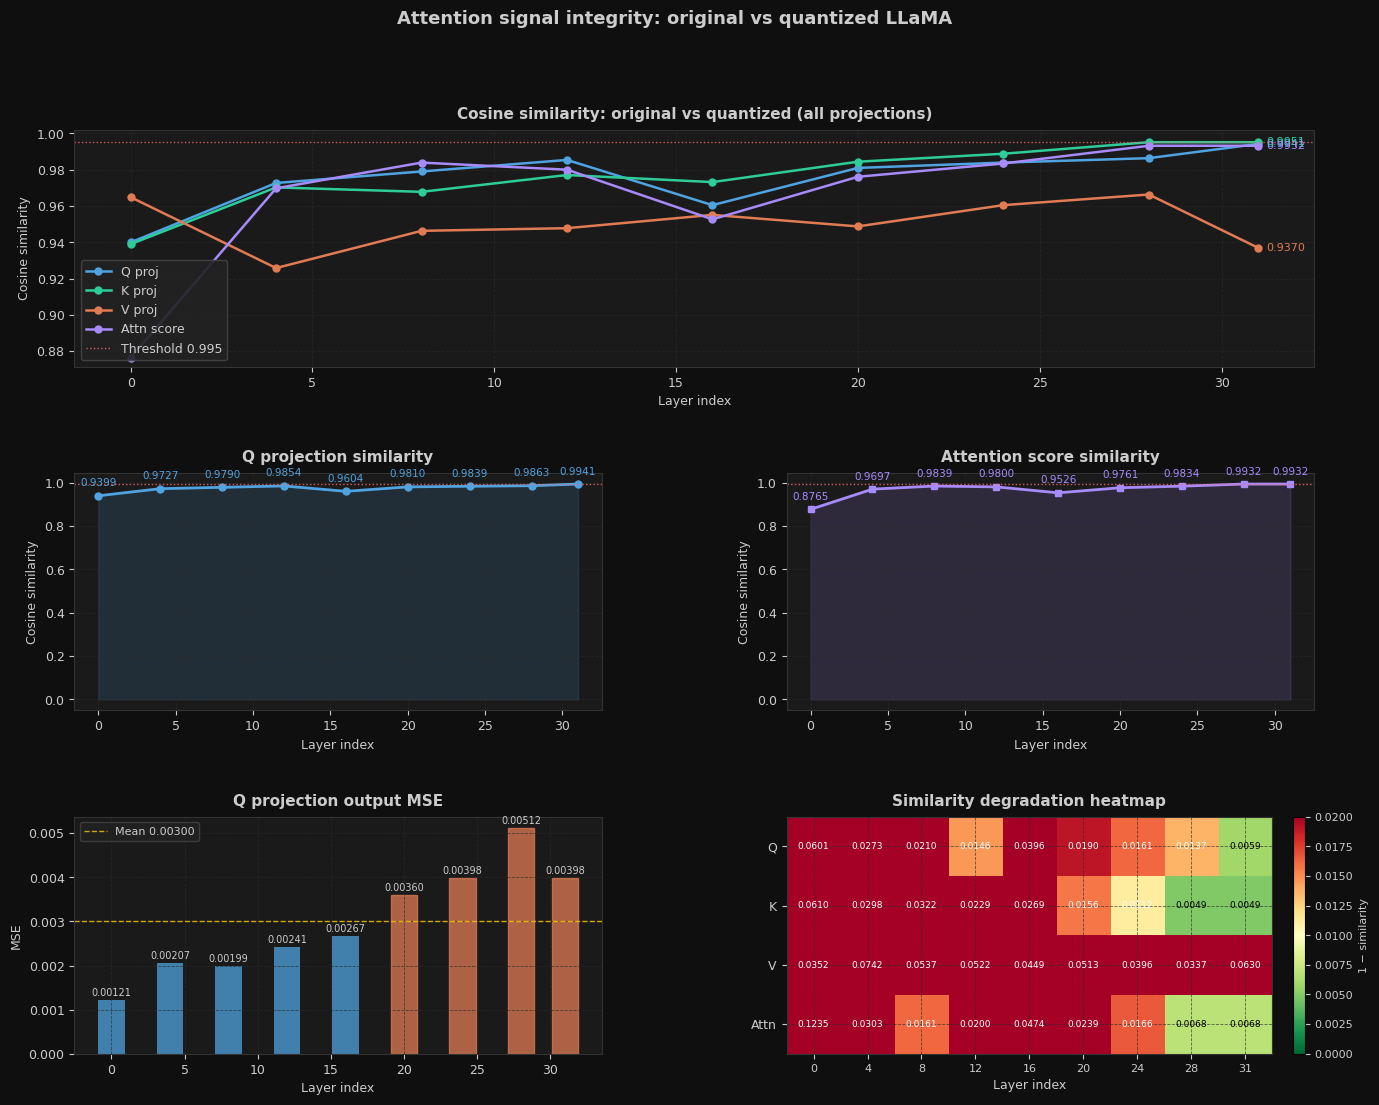

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def collect_divergence_across_layers(layer_indices, model, original_model, tokenizer):
    prompt = "The capital of France is"
    device = next(model.parameters()).device
    original_model.to(device)
    inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).to(device)
    results = []

    with torch.no_grad():
        hidden_states = original_model.model.embed_tokens(inputs.input_ids)
        position_ids  = torch.arange(
            inputs.input_ids.shape[1], device=device
        ).unsqueeze(0)
        pos_emb = model.model.rotary_emb(hidden_states, position_ids)

        for layer_idx in layer_indices:
            orig_attn  = original_model.model.layers[layer_idx].self_attn
            quant_attn = model.model.layers[layer_idx].self_attn

            q_orig  = orig_attn.q_proj(hidden_states)
            q_quant = quant_attn.q_proj(hidden_states)
            q_sim   = F.cosine_similarity(
                q_orig.flatten(), q_quant.flatten(), dim=0
            ).item()

            k_orig  = orig_attn.k_proj(hidden_states)
            k_quant = quant_attn.k_proj(hidden_states)
            k_sim   = F.cosine_similarity(
                k_orig.flatten(), k_quant.flatten(), dim=0
            ).item()

            v_orig  = orig_attn.v_proj(hidden_states)
            v_quant = quant_attn.v_proj(hidden_states)
            v_sim   = F.cosine_similarity(
                v_orig.flatten(), v_quant.flatten(), dim=0
            ).item()

            bsz, q_len, _ = hidden_states.size()
            q_o = q_orig.view(bsz, q_len, 32, 128).transpose(1, 2)
            k_o = k_orig.view(bsz, q_len, 32, 128).transpose(1, 2)
            q_o, k_o = apply_rotary_pos_emb(q_o, k_o, *pos_emb)
            attn_orig  = torch.matmul(q_o, k_o.transpose(2, 3)) / (128 ** 0.5)

            q_q = q_quant.view(bsz, q_len, 32, 128).transpose(1, 2)
            k_q = k_quant.view(bsz, q_len, 32, 128).transpose(1, 2)
            q_q, k_q = apply_rotary_pos_emb(q_q, k_q, *pos_emb)
            attn_quant = quant_attn.qkt_matmul(
                q_q, k_q.transpose(2, 3)
            ) / (128 ** 0.5)

            attn_sim = F.cosine_similarity(
                attn_orig.flatten(), attn_quant.flatten(), dim=0
            ).item()

            # weight MSE (magnitude of quantization error in weights)
            w_mse = F.mse_loss(
                q_orig, q_quant
            ).item()

            results.append({
                "layer":    layer_idx,
                "q_sim":    q_sim,
                "k_sim":    k_sim,
                "v_sim":    v_sim,
                "attn_sim": attn_sim,
                "w_mse":    w_mse,
            })
            print(f"Layer {layer_idx:2d} | "
                  f"Q:{q_sim:.4f}  K:{k_sim:.4f}  "
                  f"V:{v_sim:.4f}  Attn:{attn_sim:.4f}  "
                  f"MSE:{w_mse:.6f}")

    return results


def plot_divergence(results, save_path=None):
    layers   = [r["layer"]    for r in results]
    q_sims   = [r["q_sim"]    for r in results]
    k_sims   = [r["k_sim"]    for r in results]
    v_sims   = [r["v_sim"]    for r in results]
    attn_sims= [r["attn_sim"] for r in results]
    w_mses   = [r["w_mse"]    for r in results]

    fig = plt.figure(figsize=(16, 12))
    fig.patch.set_facecolor("#0f0f0f")
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    COLORS = {
        "Q proj":    "#4fa3e0",
        "K proj":    "#2ecc99",
        "V proj":    "#e07b54",
        "Attn score":"#a78bfa",
    }
    AX_BG   = "#1a1a1a"
    GRID_C  = "#2a2a2a"
    TEXT_C  = "#cccccc"
    THRESH  = 0.995       # cosine sim "good" threshold line

    def style_ax(ax, title):
        ax.set_facecolor(AX_BG)
        for spine in ax.spines.values():
            spine.set_edgecolor("#333333")
        ax.tick_params(colors=TEXT_C, labelsize=9)
        ax.xaxis.label.set_color(TEXT_C)
        ax.yaxis.label.set_color(TEXT_C)
        ax.set_title(title, color=TEXT_C, fontsize=11, pad=8, fontweight="bold")
        ax.grid(True, color=GRID_C, linewidth=0.6, linestyle="--", alpha=0.7)
        ax.set_xlabel("Layer index", fontsize=9)

    # ── 1. Cosine similarity — all 4 signals ─────────────────────────
    ax1 = fig.add_subplot(gs[0, :])   # full width top row
    style_ax(ax1, "Cosine similarity: original vs quantized (all projections)")
    for label, vals, color in [
        ("Q proj",     q_sims,    COLORS["Q proj"]),
        ("K proj",     k_sims,    COLORS["K proj"]),
        ("V proj",     v_sims,    COLORS["V proj"]),
        ("Attn score", attn_sims, COLORS["Attn score"]),
    ]:
        ax1.plot(layers, vals, marker="o", markersize=5,
                 linewidth=1.8, color=color, label=label)
        # annotate last point
        ax1.annotate(f"{vals[-1]:.4f}",
                     xy=(layers[-1], vals[-1]),
                     xytext=(6, 0), textcoords="offset points",
                     color=color, fontsize=8, va="center")

    ax1.axhline(THRESH, color="#ff6b6b", linewidth=1,
                linestyle=":", alpha=0.8, label=f"Threshold {THRESH}")
    ax1.set_ylabel("Cosine similarity", fontsize=9)
    ax1.legend(loc="lower left", fontsize=9,
               facecolor="#222222", edgecolor="#444444",
               labelcolor=TEXT_C, framealpha=0.9)
    ax1.set_ylim(min(min(q_sims), min(attn_sims)) - 0.005, 1.002)

    # ── 2. Q projection only (zoom) ───────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    style_ax(ax2, "Q projection similarity")
    ax2.plot(layers, q_sims, marker="o", markersize=5,
             linewidth=2, color=COLORS["Q proj"])
    ax2.fill_between(layers, q_sims, alpha=0.15, color=COLORS["Q proj"])
    ax2.axhline(THRESH, color="#ff6b6b", linewidth=1, linestyle=":", alpha=0.8)
    ax2.set_ylabel("Cosine similarity", fontsize=9)
    for x, y in zip(layers, q_sims):
        ax2.annotate(f"{y:.4f}", (x, y),
                     textcoords="offset points", xytext=(0, 7),
                     ha="center", color=COLORS["Q proj"], fontsize=7.5)

    # ── 3. Attention score similarity ────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    style_ax(ax3, "Attention score similarity")
    ax3.plot(layers, attn_sims, marker="s", markersize=5,
             linewidth=2, color=COLORS["Attn score"])
    ax3.fill_between(layers, attn_sims, alpha=0.15, color=COLORS["Attn score"])
    ax3.axhline(THRESH, color="#ff6b6b", linewidth=1, linestyle=":", alpha=0.8)
    ax3.set_ylabel("Cosine similarity", fontsize=9)
    for x, y in zip(layers, attn_sims):
        ax3.annotate(f"{y:.4f}", (x, y),
                     textcoords="offset points", xytext=(0, 7),
                     ha="center", color=COLORS["Attn score"], fontsize=7.5)

    # ── 4. Weight MSE (Q projection error) ────────────────────────────
    ax4 = fig.add_subplot(gs[2, 0])
    style_ax(ax4, "Q projection output MSE")
    bars = ax4.bar(layers, w_mses, color=COLORS["Q proj"],
                   alpha=0.75, width=max(1, (layers[-1]-layers[0])//len(layers)*0.6))
    ax4.set_ylabel("MSE", fontsize=9)
    # color bars that exceed mean red
    mean_mse = np.mean(w_mses)
    ax4.axhline(mean_mse, color="#ffcc00", linewidth=1,
                linestyle="--", alpha=0.8, label=f"Mean {mean_mse:.5f}")
    for bar, val in zip(bars, w_mses):
        if val > mean_mse:
            bar.set_color("#e07b54")
        ax4.text(bar.get_x() + bar.get_width()/2, val + max(w_mses)*0.01,
                 f"{val:.5f}", ha="center", va="bottom",
                 color=TEXT_C, fontsize=7)
    ax4.legend(fontsize=8, facecolor="#222222",
               edgecolor="#444444", labelcolor=TEXT_C)

    # ── 5. Degradation heatmap across all signals ────────────────────
    ax5 = fig.add_subplot(gs[2, 1])
    style_ax(ax5, "Similarity degradation heatmap")
    matrix = np.array([q_sims, k_sims, v_sims, attn_sims])   # (4, L)
    im = ax5.imshow(1 - matrix, aspect="auto", cmap="RdYlGn_r",
                    vmin=0, vmax=0.02, interpolation="nearest")
    ax5.set_yticks(range(4))
    ax5.set_yticklabels(["Q", "K", "V", "Attn"], color=TEXT_C, fontsize=9)
    ax5.set_xticks(range(len(layers)))
    ax5.set_xticklabels([str(l) for l in layers], color=TEXT_C, fontsize=8)
    ax5.set_xlabel("Layer index", fontsize=9)
    for i in range(4):
        for j in range(len(layers)):
            val = 1 - matrix[i, j]
            ax5.text(j, i, f"{val:.4f}", ha="center", va="center",
                     fontsize=6.5, color="black" if val < 0.01 else "white")
    cbar = fig.colorbar(im, ax=ax5, fraction=0.04, pad=0.04)
    cbar.ax.yaxis.set_tick_params(color=TEXT_C, labelsize=8)
    cbar.set_label("1 − similarity", color=TEXT_C, fontsize=8)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT_C)

    fig.suptitle(
        "Attention signal integrity: original vs quantized LLaMA",
        color=TEXT_C, fontsize=13, fontweight="bold", y=0.98
    )

    plt.savefig(save_path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor()) if save_path else plt.show()
    plt.show()
    plt.close(fig)
    print(f"Saved to {save_path}" if save_path else "Plot displayed")


# ── Run ───────────────────────────────────────────────────────────────
layer_indices   = list(range(0, 32, 4))   # every 4th layer: 0,4,8..28 + 31
layer_indices  += [31]
layer_indices   = sorted(set(layer_indices))

divergence_data = collect_divergence_across_layers(
    layer_indices, lm.model, original_model, lm.tokenizer
)



#### Diagnosis-heat map
Layer 0  → worst across all signals, especially Attn (0.1235)
Layer 4  → V projection outlier (0.0742)
Layer 12 → secondary spike in Q and Attn
Layers 24–31 → model has learned well, all signals < 0.007

In [39]:
import torch
import torch.nn.functional as F

def debug_attention_divergence(layer_idx, model, original_model, tokenizer):
    prompt = "The capital of France is"
    device = next(model.parameters()).device
    original_model.to(device)
    inputs = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).to(device)
   
    with torch.no_grad():
        # 1. Get input to the layer
        hidden_states = original_model.model.embed_tokens(inputs.input_ids)
        position_ids = torch.arange(inputs.input_ids.shape[1], device=inputs.input_ids.device).unsqueeze(0).to(device)
        pos_emb = model.model.rotary_emb(hidden_states, position_ids)
        
        orig_layer = original_model.model.layers[layer_idx].self_attn
        quant_layer = model.model.layers[layer_idx].self_attn
        
        # 2. Compare Q Projections (Checking Weight Quantization)
        q_orig = orig_layer.q_proj(hidden_states)
        q_quant = quant_layer.q_proj(hidden_states)
        
        q_sim = F.cosine_similarity(q_orig.flatten(), q_quant.flatten(), dim=0)
        
        # 3. Compare Attention Scores (Checking Activation Scaling/MatMul)
        # We'll simulate the first part of the forward pass
        bsz, q_len, _ = hidden_states.size()
        
        # Original Attention Score
        q_o = q_orig.view(bsz, q_len, 32, 128).transpose(1, 2)
        k_o = orig_layer.k_proj(hidden_states).view(bsz, q_len, 32, 128).transpose(1, 2)
        # Apply RoPE (using the standard function)
        q_o, k_o = apply_rotary_pos_emb(q_o, k_o, *pos_emb)
        attn_orig = torch.matmul(q_o, k_o.transpose(2, 3)) / (128**0.5)
        
        # Quantized Attention Score
        q_q = q_quant.view(bsz, q_len, 32, 128).transpose(1, 2)
        k_q = quant_layer.k_proj(hidden_states).view(bsz, q_len, 32, 128).transpose(1, 2)
        q_q, k_q = apply_rotary_pos_emb(q_q, k_q, *pos_emb)
        
        # Use your custom QuantMatMul logic
        attn_quant = quant_layer.qkt_matmul(q_q, k_q.transpose(2, 3)) / (128**0.5)
        
        attn_sim = F.cosine_similarity(attn_orig.flatten(), attn_quant.flatten(), dim=0)

    print(f"--- Layer {layer_idx} Signal Integrity ---")
    print(f"Q-Projection Cosine Sim: {q_sim.item():.6f}")
    print(f"Attention Score Cosine Sim: {attn_sim.item():.6f}")

debug_attention_divergence(31, lm.model, original_model, tokenizer_fp)

--- Layer 31 Signal Integrity ---
Q-Projection Cosine Sim: 0.994141
Attention Score Cosine Sim: 0.993164


In [68]:
# Before running PPL
for m in lm.model.modules():
    if hasattr(m, 'set_quant_state'):
        m.set_quant_state(weight_quant=True, act_quant=False)

In [118]:
from datasets import load_dataset
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")
ppl=evaluate(lm.model, tokenizer_fp, dataset, device=lm.device, seq_len=512, nsamples=10,quant_state=True)

2026-03-18 17:16:06,296 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/wikitext/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-03-18 17:16:06,547 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/Salesforce/wikitext/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-03-18 17:16:06,581 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/Salesforce/wikitext/b08601e04326c79dfdd32d625aee71d232d685c3/README.md "HTTP/1.1 200 OK"
2026-03-18 17:16:06,845 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/wikitext/resolve/b08601e04326c79dfdd32d625aee71d232d685c3/wikitext.py "HTTP/1.1 307 Temporary Redirect"
2026-03-18 17:16:07,127 - INFO - HTTP Request: HEAD https://huggingface.co/datasets/Salesforce/wikitext/resolve/b08601e04326c79dfdd32d625aee71d232d685c3/wikitext.py "HTTP/1.1 404 Not Found"
2026-03-18 17:16:08,086 - INFO - HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/w

 10%|█         | 1/10 [00:04<00:38,  4.32s/it]

Batch 0 Loss: 2.95703125


 20%|██        | 2/10 [00:08<00:33,  4.16s/it]

Batch 1 Loss: 3.1328125


...

Batch 7 Loss: 2.78125


 90%|█████████ | 9/10 [00:36<00:04,  4.06s/it]

Batch 8 Loss: 3.1015625


100%|██████████| 10/10 [00:40<00:00,  4.08s/it]

Batch 9 Loss: 4.546875


In [52]:
ppl

13.171875

In [102]:
lm.model.load_state_dict(torch.load("../save_improved/current_model.pth"), strict=False)

<All keys matched successfully>

In [35]:
layer_0=torch.load("./quant_layers/layer_0.pt")

In [37]:
layer_0

OrderedDict([('qkt_smooth_scale',
              tensor([1.1406, 1.2598, 0.7783,  ..., 1.7090, 2.6562, 2.1133],
                     dtype=torch.float16)),
             ('qkv_smooth_shift',
              tensor([0., 0., 0.,  ..., 0., 0., 0.], dtype=torch.float16)),
             ('qkv_smooth_scale',
              tensor([0.5752, 0.1030, 0.0219,  ..., 0.0100, 0.0932, 0.0323],
                     dtype=torch.float16)),
             ('self_attn_q_proj_smooth_rotate',
              tensor([[1.],
                      [1.],
                      [1.],
                      ...,
                      [1.],
                      [1.],
                      [1.]], dtype=torch.float16)),
             ('out_smooth_shift',
              tensor([0., 0., 0.,  ..., 0., 0., 0.], dtype=torch.float16)),
             ('out_smooth_scale',
              tensor([ 0.0200,  0.0889,  1.6895,  ...,  0.0861, -0.0757,  0.0359],
                     dtype=torch.float16)),
             ('self_attn_o_proj_smooth_rot

In [122]:
lm.model.model.layers[0].self_attn.q_proj.weight_quantizer.scales

tensor([[2.9349e-04],
        [7.5221e-05],
        [3.4761e-04],
        ...,
        [1.9288e-04],
        [6.6710e-04],
        [2.4509e-04]], device='cuda:0', dtype=torch.float16)

### KG evaluation

In [74]:
import importlib

In [91]:
dir_with_spaces = os.path.abspath("../Knowledge graph extraction") 

# Insert the directory at the beginning of the search path
sys.path.insert(0, dir_with_spaces)
import KG
importlib.reload(KG)

<module 'KG' from 'c:\\Users\\CT-PROJECT\\Documents\\Team10_FYP\\FYP\\Knowledge graph extraction\\KG.py'>

In [92]:
KG.evaluate(tokenizer_fp,lm.model)

Both `max_new_tokens` (=50) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Sentence: But that spasm of irritation by a master intimidator was minor compared with what Bobby Fischer , the erratic former world chess champion , dished out in March at a news conference in Reykjavik , Iceland .
GT   : ['iceland', 'reykjavik', 'bobby fischer']
Pred : ['dished out in March at a news conference in Reykjavik', 'For example:', 'Iceland', 'the erratic former world chess champion', 'Sentence: Barack Obama visited New York', 'Entities: Barack Obama', 'Extract named entities from the sentence with Capitalization. Only output the entities without any explanation or extra text. Separate entities with commas or new lines', 'Entities:', 'New York', 'Sentence: But that spasm of irritation by a master intimidator was minor compared with what Bobby Fischer']
P=0.10, R=0.33, F1=0.15


Both `max_new_tokens` (=50) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Sentence: But Schaap seems as comfortable in that role as Joe Buck , the Fox baseball and football sportscaster who so clearly benefited from learning beside his father , Jack Buck , the late voice of the St. Louis Cardinals . ''
GT   : ['fox', 'jack buck', 'joe buck', 'st. louis cardinals']
Pred : ['the Fox baseball and football sportscaster who so clearly benefited from learning beside his father', 'For example:', 'Jack Buck', "the late voice of the St. Louis Cardinals . ''", 'Card', 'Sentence: Barack Obama visited New York', 'Sentence: But Schaap seems as comfortable in that role as Joe Buck', 'Entities: Barack Obama', 'Extract named entities from the sentence with Capitalization. Only output the entities without any explanation or extra text. Separate entities with commas or new lines', 'Entities:', 'New York']
P=0.09, R=0.25, F1=0.13


Both `max_new_tokens` (=50) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


Sentence: OVER the last few years , as its residents fought a battle against the city to keep their homes , the Fort Trumbull neighborhood of New London looked more and more like a war-torn village , with acres of vacant lots interrupted intermittently by debris and a few scattered houses .
GT   : ['new london', 'fort trumbull']
Pred : ['with acres of vacant lots interrupted intermittently by debris and a few scattered houses', 'For example:', 'the Fort Trumbull neighborhood of New London looked more and more like a wartorn village', 'as its residents fought a battle against the city to keep their homes', 'Sentence: Barack Obama visited New York', 'Entities: Barack Obama', 'Extract named entities from the sentence with Capitalization. Only output the entities without any explanation or extra text. Separate entities with commas or new lines', 'Sentence: OVER the last few years', 'Entities:', 'New York']
P=0.00, R=0.00, F1=0.00


Both `max_new_tokens` (=50) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Sentence: Curry and Crawford , close friends and longtime teammates in Chicago and New York , were in sync in the final quarter .
GT   : ['new york', 'curry', 'crawford', 'chicago']
Pred : ['Sentence: Curry and Crawford', 'close friends and longtime teammates in Chicago and New York', 'For example:', 'were in sync in the final quarter', 'Sentence: Barack Obama visited New York', 'Entities: Barack Obama', "S......'", 'Extract named entities from the sentence with Capitalization. Only output the entities without any explanation or extra text. Separate entities with commas or new lines', 'Entities:', 'New York']
P=0.10, R=0.25, F1=0.14


Both `max_new_tokens` (=50) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Sentence: The Knicks were 10 for 15 from the free-throw line in the fourth quarter , but had only 2 turnovers , and Coach Isiah Thomas called it a vast improvement from their fourth quarter in Chicago . ''
GT   : ['chicago', 'isiah thomas']
Pred : ['Sentence: The Knicks were 10 for 15 from the freethrow line in the fourth quarter', 'For example:', "and Coach Isiah Thomas called it a vast improvement from their fourth quarter in Chicago . ''", 'Sentence: Barack Obama visited New York', 'Entities: Barack Obama', 'Extract named entities from the sentence with Capitalization. Only output the entities without any explanation or extra text. Separate entities with commas or new lines', 'but had only 2 turnovers', 'Entities:', 'New York']
P=0.00, R=0.00, F1=0.00

Sentence: Nanette Lepore , a New York fashion designer , said she reserved a seat every week to go to her home in Amagansett because she '' ca n't bear standing , especially when I 've worked all day and I 'm stressed out . ''
GT   :

In [ ]:

for name, module in lm.model.named_modules():
            if isinstance(module, QuantLinear):
                del module.weight_quantizer.upbound_factor
                del module.weight_quantizer.lowbound_factor
            if isinstance(module,QuantLlamaDecoderLayer):
                if args.let:
                    del module.qkv_smooth_scale
                    del module.qkv_smooth_shift
                    del module.out_smooth_scale
                    del module.out_smooth_shift
                    del module.fc1_smooth_scale
                    del module.fc1_smooth_shift
                               
lm.model.save_pretrained('../save_dir')  
lm.tokenizer.save_pretrained('../save_dir')        # delete rlq parameters
        

Writing model shards: 100%|██████████| 1/1 [00:47<00:00, 47.53s/it]


('../save_improved\\tokenizer_config.json', '../save_improved\\tokenizer.json')

In [122]:
import os, json, torch
from safetensors.torch import save_file

def save_fake_quant_model(lm, args, 
                          QuantLlamaDecoderLayer, QuantLinear):
    os.makedirs(args.save_dir, exist_ok=True)

    # ── Step 1: bake smooth/quant params & clean up learnable params ──
    for name, module in lm.model.named_modules():
        if isinstance(module, QuantLinear):
            # Remove LWC learnable factors (already baked into weight)
            if hasattr(module.weight_quantizer, 'lowbound_factor'):
                del module.weight_quantizer.lowbound_factor
            if hasattr(module.weight_quantizer, 'upbound_factor'):
                del module.weight_quantizer.upbound_factor
        if isinstance(module, QuantLlamaDecoderLayer):
            if args.let:
                for attr in ['qkv_smooth_scale','qkv_smooth_shift',
                             'out_smooth_scale','out_smooth_shift',
                             'fc1_smooth_scale','fc1_smooth_shift']:
                    if hasattr(module, attr):
                        delattr(module, attr)

    # ── Step 2: Save full state dict (includes scales/zeros buffers) ──
    state_dict = lm.model.state_dict()
    save_file(state_dict, os.path.join(args.save_dir, "model.safetensors"))

    # ── Step 3: Save config (standard HF config) ──
    lm.model.config.to_json_file(os.path.join(args.save_dir, "config.json"))
    lm.tokenizer.save_pretrained(args.save_dir)

    # ── Step 4: Save a quant_config so you know how to reload ──
    quant_config = {
        "quant_type": "fake_quant_llama",
        "n_bits": args.weight_quant_params["n_bits"],
        "group_size": args.weight_quant_params.get("group_size", None),
        "symmetric": args.weight_quant_params["symmetric"],
        "let": args.let,
    }
    with open(os.path.join(args.save_dir, "quant_config.json"), "w") as f:
        json.dump(quant_config, f, indent=2)

    print(f"Saved fake-quant model to {args.save_dir}")

In [123]:
save_fake_quant_model(lm, args, QuantLlamaDecoderLayer, QuantLinear)

Saved fake-quant model to ../save_dir


In [124]:
@torch.no_grad()
def export_to_int8(model, save_dir):
    """
    Manually convert fake-quant fp16 weights → int8 integers
    using the already-registered scales and zeros.
    """
    int8_state = {}
    
    for name, module in model.named_modules():
        if isinstance(module, QuantLinear):
            q   = module.weight_quantizer
            w   = module.weight          # fp16, already smoothed & fake-quant baked
            s   = q.scales               # registered buffer
            z   = q.zeros                # registered buffer

            if q.group_size:
                w_g = w.reshape(-1, q.group_size)
            else:
                w_g = w

            # Convert to integer
            w_int = (w_g / s).round().add(z).clamp(0, 255).to(torch.uint8)
            w_int = w_int.reshape(w.shape)

            int8_state[f"{name}.weight_int8"] = w_int
            int8_state[f"{name}.scales"]      = s
            int8_state[f"{name}.zeros"]        = z

    os.makedirs(save_dir, exist_ok=True)
    torch.save(int8_state, os.path.join(save_dir, "int8_weights.pt"))
    print(f"Saved int8 weights to {save_dir}/int8_weights.pt")
    
    return int8_state

int8_state = export_to_int8(lm.model, args.save_dir)

Saved int8 weights to ../save_dir/int8_weights.pt


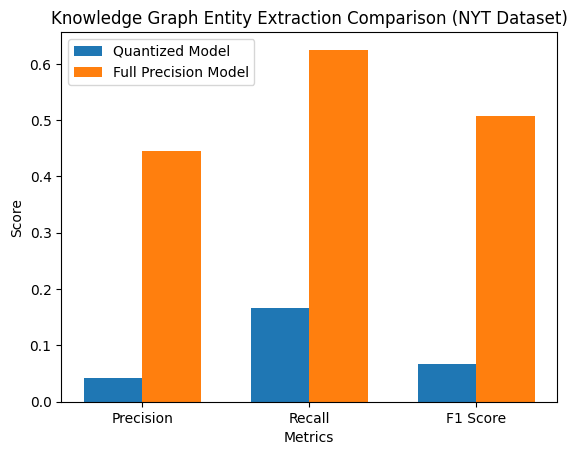

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Your values
quantized = [0.0429, 0.1667, 0.0674]   # Precision, Recall, F1
full_precision = [0.4452, 0.6250, 0.5071]

metrics = ["Precision", "Recall", "F1 Score"]

x = np.arange(len(metrics))
width = 0.35

plt.figure()

plt.bar(x - width/2, quantized, width, label="Quantized Model")
plt.bar(x + width/2, full_precision, width, label="Full Precision Model")

plt.xlabel("Metrics")
plt.ylabel("Score")
plt.title("Knowledge Graph Entity Extraction Comparison (NYT Dataset)")
plt.xticks(x, metrics)
plt.legend()

plt.show()